# **Modelling LSTM**

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import json, time, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, f1_score, recall_score,
                             classification_report, confusion_matrix)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')

RANDOM = 42
random.seed(RANDOM); np.random.seed(RANDOM)
tf.keras.utils.set_random_seed(RANDOM)

print('TensorFlow:', tf.__version__, '| Keras:', keras.__version__)

TensorFlow: 2.21.0 | Keras: 3.14.0


## Load Dataset


In [2]:
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == 'notebooks' else CURRENT_DIR
DATA_PATH = PROJECT_ROOT / 'data' / 'final for modelling' / 'dataset_final_new.csv'
DIR_OUTPUT = PROJECT_ROOT / 'notebooks' / 'outputs'
DIR_OUTPUT.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset tidak ditemukan: {DATA_PATH}')

df_raw = pd.read_csv(DATA_PATH, parse_dates=['tanggal'])
TARGET = 'ISPU PM2.5'
KATEGORI = 'kategori_pm25'
print('Dataset    :', DATA_PATH)
print('Shape      :', df_raw.shape)
print('Tanggal    :', df_raw['tanggal'].min().date(), '->', df_raw['tanggal'].max().date())
display(df_raw.head())

Dataset    : c:\Users\User\Air Pollution - Daming Project\data\final for modelling\dataset_final_new.csv
Shape      : (7672, 12)
Tanggal    : 2022-01-01 -> 2024-12-31


,tanggal,ISPU PM2.5,kategori_pm25,bulan,hari_minggu,temp,humidity,visibility,windgust,solarenergy,precip,station
0,2022-01-01,74.0,Sedang,1,5,28.6,77.2,6.7,37.1,20.6,0.496,bundaran hi
1,2022-01-01,73.0,Sedang,1,5,28.3,77.8,6.8,37.1,20.6,0.502,jagakarsa
2,2022-01-01,69.0,Sedang,1,5,28.3,79.3,7.5,37.1,20.6,0.645,kebun jeruk
3,2022-01-01,76.0,Sedang,1,5,28.6,76.9,6.7,34.9,21.0,0.262,kelapa gading
4,2022-01-01,87.0,Sedang,1,5,28.5,76.8,6.2,34.9,21.0,0.451,lubang buaya


## Cek Struktur Data, Missing Value, Target & Distribusi Kategori PM2.5


In [3]:
print('Info kolom & tipe:')
display(df_raw.dtypes.to_frame('tipe'))
print('Missing per kolom:')
display(df_raw.isna().sum().to_frame('missing'))
print('Statistik target ISPU PM2.5:')
display(df_raw[TARGET].describe().to_frame())
print('Distribusi kategori PM2.5 (dari dataset):')
display(df_raw[KATEGORI].value_counts().to_frame('jumlah'))

Info kolom & tipe:


,tipe
tanggal,datetime64[us]
ISPU PM2.5,float64
kategori_pm25,str
bulan,int64
hari_minggu,int64
temp,float64
humidity,float64
visibility,float64
windgust,float64
solarenergy,float64


Missing per kolom:


,missing
tanggal,0
ISPU PM2.5,0
kategori_pm25,0
bulan,0
hari_minggu,0
temp,0
humidity,0
visibility,0
windgust,0
solarenergy,0


Statistik target ISPU PM2.5:


,ISPU PM2.5
count,7672.000000
mean,71.916835
std,22.823113
min,0.000000
25%,62.257781
50%,74.000000
75%,85.708333
max,224.875000


Distribusi kategori PM2.5 (dari dataset):


,jumlah
kategori_pm25,
Sedang,6098
Baik,1023
Tidak Sehat,548
Sangat Tidak Sehat,3


## Feature Engineering

In [4]:
KOLOM_CUACA = ['temp', 'humidity', 'visibility', 'windgust', 'solarenergy', 'precip']
data_fitur = df_raw.copy()
sc_cols = sorted(c for c in data_fitur.columns if c.startswith('station_'))

# Dataset terbaru menyimpan nama station sebagai teks. Tetap dukung format lama one-hot.
if 'station' not in data_fitur.columns:
    if not sc_cols:
        raise ValueError('Kolom station maupun station_* tidak ditemukan.')
    data_fitur['station'] = data_fitur[sc_cols].idxmax(axis=1).str.replace('station_', '', regex=False)
else:
    data_fitur['station'] = data_fitur['station'].astype(str).str.strip().str.lower()

if not sc_cols:
    station_dummies = pd.get_dummies(data_fitur['station'], prefix='station', dtype=float)
    data_fitur = pd.concat([data_fitur, station_dummies], axis=1)
    sc_cols = sorted(station_dummies.columns.tolist())
else:
    data_fitur[sc_cols] = data_fitur[sc_cols].astype(float)

# Buang baris tanpa data cuaca sama sekali (2025-01-01)
mask_dangling = data_fitur[KOLOM_CUACA].isna().all(axis=1)
print(f'Baris tanpa cuaca yang dibuang: {int(mask_dangling.sum())}')
data_fitur = data_fitur[~mask_dangling].reset_index(drop=True)

data_fitur = data_fitur.sort_values(['station', 'tanggal']).reset_index(drop=True)
if data_fitur.duplicated(['station', 'tanggal']).any():
    raise ValueError('Terdapat tanggal duplikat pada station yang sama.')
data_fitur['bulan_sin'] = np.sin(2 * np.pi * data_fitur['bulan'] / 12)
data_fitur['bulan_cos'] = np.cos(2 * np.pi * data_fitur['bulan'] / 12)
data_fitur['hari_minggu_sin'] = np.sin(2 * np.pi * data_fitur['hari_minggu'] / 7)
data_fitur['hari_minggu_cos'] = np.cos(2 * np.pi * data_fitur['hari_minggu'] / 7)
data_fitur['is_weekend'] = data_fitur['hari_minggu'].isin([5, 6]).astype(int)
data_fitur['musim_hujan'] = data_fitur['bulan'].isin([11, 12, 1, 2, 3, 4]).astype(int)

# Daftar fitur per timestep (target ikut sebagai input historis)
FITUR_LSTM = ([TARGET] + KOLOM_CUACA +
              ['bulan_sin', 'bulan_cos', 'hari_minggu_sin', 'hari_minggu_cos', 'is_weekend', 'musim_hujan'] + sc_cols)

# Isi missing INPUT hanya dari observasi masa lalu pada station yang sama.
# Target tidak diimputasi agar label hasil rekayasa tidak masuk ke pelatihan.
fitur_tanpa_target = [c for c in FITUR_LSTM if c != TARGET]
data_fitur[fitur_tanpa_target] = data_fitur.groupby('station')[fitur_tanpa_target].ffill()

print(f'Jumlah fitur per timestep : {len(FITUR_LSTM)}')
print('Sample fitur:', FITUR_LSTM[:10], '...')
print('Kolom dummy station:', sc_cols)

Baris tanpa cuaca yang dibuang: 0
Jumlah fitur per timestep : 20
Sample fitur: ['ISPU PM2.5', 'temp', 'humidity', 'visibility', 'windgust', 'solarenergy', 'precip', 'bulan_sin', 'bulan_cos', 'hari_minggu_sin'] ...
Kolom dummy station: ['station_bundaran hi', 'station_jagakarsa', 'station_kebun jeruk', 'station_kelapa gading', 'station_lubang buaya', 'station_us embassy 1', 'station_us embassy 2']


## Cek Missing Value
Missing input diisi dengan **forward fill per station** agar hanya memakai observasi masa lalu. Target tidak pernah diimputasi.


In [5]:
# Cek missing value pada fitur LSTM dan target sebelum modelling
missing_fitur = data_fitur[FITUR_LSTM].isna().sum().rename('missing').to_frame()
missing_fitur['persen'] = (missing_fitur['missing'] / len(data_fitur) * 100).round(3)
missing_target = int(data_fitur[TARGET].isna().sum())

print(f'Total baris setelah feature engineering : {len(data_fitur):,}')
print(f'Missing target ({TARGET}) : {missing_target}')
print(f'Total kolom fitur LSTM : {len(FITUR_LSTM)}')

# Target tidak boleh kosong, drop baris dengan target NaN
if missing_target > 0:
    n_sebelum = len(data_fitur)
    data_fitur = data_fitur.dropna(subset=[TARGET]).reset_index(drop=True)
    print(f'Dibuang {n_sebelum - len(data_fitur)} baris dengan target kosong. Baris tersisa: {len(data_fitur):,}')
else:
    print('target tidak ada yang kosong.')

# Sisa NaN input biasanya berada di awal riwayat station. Jangan pakai bfill/median
# dari masa depan; buang baris tersebut dan cegah sequence melompati gap tanggal.
mask_input_missing = data_fitur[fitur_tanpa_target].isna().any(axis=1)
if mask_input_missing.any():
    print(f'Dibuang {int(mask_input_missing.sum())} baris dengan input historis belum tersedia.')
    data_fitur = data_fitur.loc[~mask_input_missing].reset_index(drop=True)

print('Sisa missing pada fitur input setelah imputasi:',
      int(data_fitur[fitur_tanpa_target].isna().sum().sum()))
print('Sisa missing pada target:', int(data_fitur[TARGET].isna().sum()))

# Tabel ringkas top-10 missing (sebelum imputasi)
display(missing_fitur.sort_values('missing', ascending=False).head(10))


Total baris setelah feature engineering : 7,672
Missing target (ISPU PM2.5) : 0
Total kolom fitur LSTM : 20
target tidak ada yang kosong.
Sisa missing pada fitur input setelah imputasi: 0
Sisa missing pada target: 0


,missing,persen
ISPU PM2.5,0,0.0
temp,0,0.0
humidity,0,0.0
visibility,0,0.0
windgust,0,0.0
solarenergy,0,0.0
precip,0,0.0
bulan_sin,0,0.0
bulan_cos,0,0.0
hari_minggu_sin,0,0.0


## Build Sequence per Stasiun (Sliding Window)

In [6]:
LOOKBACK = 14

def bangun_sequences(df, fitur, target, lookback):
    X_list, y_list, tgl_list, st_list = [], [], [], []
    for st, sub in df.groupby('station'):
        sub = sub.sort_values('tanggal').reset_index(drop=True)
        arr = sub[fitur].values.astype(np.float32)
        y = sub[target].values.astype(np.float32)
        tgl = pd.to_datetime(sub['tanggal']).values.astype('datetime64[D]')
        for i in range(lookback, len(sub)):
            if not np.all(np.diff(tgl[i - lookback:i + 1]) == np.timedelta64(1, 'D')):
                continue  # Jangan bentuk sequence yang melompati tanggal hilang.
            X_list.append(arr[i - lookback:i])
            y_list.append(y[i])
            tgl_list.append(tgl[i])
            st_list.append(st)
    return (np.stack(X_list), np.array(y_list, dtype=np.float32),
            pd.to_datetime(np.array(tgl_list)), np.array(st_list))


X_seq, y_seq, tanggal_seq, stasiun_seq = bangun_sequences(data_fitur, FITUR_LSTM, TARGET, LOOKBACK)
print(f'LOOKBACK              : {LOOKBACK} hari')
print(f'Jumlah sequence total : {len(X_seq)}')
print(f'Shape input (N, L, F) : {X_seq.shape}')
print(f'Shape target          : {y_seq.shape}')
print(f'Rentang tanggal target: {tanggal_seq.min().date()} -> {tanggal_seq.max().date()}')

LOOKBACK              : 14 hari
Jumlah sequence total : 7574
Shape input (N, L, F) : (7574, 14, 20)
Shape target          : (7574,)
Rentang tanggal target: 2022-01-15 -> 2024-12-31


### Verifikasi Sequence per Stasiun & Anti-Leakage

1. **Per stasiun**: setiap sample sequence dibangun dari riwayat satu stasiun
2. **Anti-leakage**: untuk target hari ke-`i`, input sequence memuat **fitur hari `i-LOOKBACK` s.d. `i-1`**, sehingga nilai `ISPU PM2.5` di **hari target tidak ikut masuk ke input**. Nilai `ISPU PM2.5` di dalam input adalah **riwayat (lag)**, analog dengan fitur `pm25_lag_1/3/7` di Random Forest.
3. Target `y_seq[i]` harus sama dengan `ISPU PM2.5` aktual pada hari target di dataset asli.


In [7]:
# 1) Cek bahwa sequence dibangun per stasiun
stasiun_unik = pd.Series(stasiun_seq).value_counts().sort_index()
print('Jumlah sequence per stasiun (harus tersebar per stasiun, bukan campur):')
display(stasiun_unik.to_frame('jumlah_sequence'))

# 2) Verifikasi anti-leakage pada 5 sample acak
idx_pm25_di_fitur = FITUR_LSTM.index(TARGET)
rng = np.random.RandomState(0)
sampel = rng.choice(len(X_seq), size=5, replace=False)
print(f'\nVerifikasi: input sequence berisi PM2.5 HISTORIS (hari i-{LOOKBACK} s.d. i-1),')
print('target adalah PM2.5 hari ke-i. Jika lolos -> tidak ada kebocoran target ke input.\n')
print('-' * 100)
for k in sampel:
    st = stasiun_seq[k]
    t_target = pd.Timestamp(tanggal_seq[k])
    sub = data_fitur[data_fitur['station'] == st].sort_values('tanggal').reset_index(drop=True)
    pos_target = sub.index[sub['tanggal'] == t_target][0]
    pm25_hari_sebelum_target = float(sub.loc[pos_target - 1, TARGET])
    pm25_di_input_terakhir = float(X_seq[k, -1, idx_pm25_di_fitur])
    pm25_hari_target_asli = float(sub.loc[pos_target, TARGET])
    target_y = float(y_seq[k])
    print(f'st={st} target_date={t_target.date()} | y_seq={target_y:7.2f} '
          f'| X[-1,PM25]={pm25_di_input_terakhir:7.2f} (== PM2.5 hari sebelumnya={pm25_hari_sebelum_target:7.2f}) '
          f'| PM2.5 hari target asli={pm25_hari_target_asli:7.2f}')
    assert abs(target_y - pm25_hari_target_asli) < 1e-3, 'y_seq harus = PM2.5 hari target asli'
    assert abs(pm25_di_input_terakhir - pm25_hari_sebelum_target) < 1e-3, \
        'KEBOCORAN: nilai PM2.5 hari target ikut masuk ke input!'

print('\nLolos: sequence aman dari kebocoran target. PM2.5 pada input murni historis (lag).')
print(f'Setiap sample = {LOOKBACK} hari riwayat -> prediksi PM2.5 hari berikutnya.')


Jumlah sequence per stasiun (harus tersebar per stasiun, bukan campur):


,jumlah_sequence
bundaran hi,1082
jagakarsa,1082
kebun jeruk,1082
kelapa gading,1082
lubang buaya,1082
us embassy 1,1082
us embassy 2,1082



Verifikasi: input sequence berisi PM2.5 HISTORIS (hari i-14 s.d. i-1),
target adalah PM2.5 hari ke-i. Jika lolos -> tidak ada kebocoran target ke input.

----------------------------------------------------------------------------------------------------
st=us embassy 2 target_date=2022-01-18 | y_seq=  66.11 | X[-1,PM25]=  77.54 (== PM2.5 hari sebelumnya=  77.54) | PM2.5 hari target asli=  66.11
st=bundaran hi target_date=2022-09-01 | y_seq=  74.00 | X[-1,PM25]=  74.00 (== PM2.5 hari sebelumnya=  74.00) | PM2.5 hari target asli=  74.00
st=lubang buaya target_date=2023-12-07 | y_seq=  89.00 | X[-1,PM25]=  91.79 (== PM2.5 hari sebelumnya=  91.79) | PM2.5 hari target asli=  89.00
st=bundaran hi target_date=2024-09-20 | y_seq=  81.21 | X[-1,PM25]=  74.00 (== PM2.5 hari sebelumnya=  74.00) | PM2.5 hari target asli=  81.21
st=lubang buaya target_date=2023-05-28 | y_seq= 119.38 | X[-1,PM25]= 137.58 (== PM2.5 hari sebelumnya= 137.58) | PM2.5 hari target asli= 119.38

Lolos: sequence aman dari

## Time-based Split 70/15/15 (Train / Validation / Test)

In [8]:
def bagi_data_waktu_seq(tanggal, porsi_latih=0.70, porsi_validasi=0.15):
    tanggal_unik = np.array(sorted(np.unique(tanggal)))
    n = len(tanggal_unik)
    batas_latih = pd.Timestamp(tanggal_unik[int(n * porsi_latih)])
    batas_validasi = pd.Timestamp(tanggal_unik[int(n * (porsi_latih + porsi_validasi))])
    return (tanggal < batas_latih,
            (tanggal >= batas_latih) & (tanggal < batas_validasi),
            tanggal >= batas_validasi,
            batas_latih, batas_validasi)


mask_latih, mask_validasi, mask_uji, batas_latih, batas_validasi = bagi_data_waktu_seq(tanggal_seq)

X_latih, y_latih = X_seq[mask_latih], y_seq[mask_latih]
X_validasi, y_validasi = X_seq[mask_validasi], y_seq[mask_validasi]
X_uji, y_uji = X_seq[mask_uji], y_seq[mask_uji]

info_pembagian = pd.DataFrame([
    {'subset': 'Train', 'baris': int(mask_latih.sum()),
     'mulai': tanggal_seq[mask_latih].min().date(), 'akhir': tanggal_seq[mask_latih].max().date()},
    {'subset': 'Validation', 'baris': int(mask_validasi.sum()),
     'mulai': tanggal_seq[mask_validasi].min().date(), 'akhir': tanggal_seq[mask_validasi].max().date()},
    {'subset': 'Test', 'baris': int(mask_uji.sum()),
     'mulai': tanggal_seq[mask_uji].min().date(), 'akhir': tanggal_seq[mask_uji].max().date()},
])
print('Train berakhir sebelum:', batas_latih.date(), '| Validation berakhir sebelum:', batas_validasi.date())
display(info_pembagian)

Train berakhir sebelum: 2024-02-11 | Validation berakhir sebelum: 2024-07-22


,subset,baris,mulai,akhir
0,Train,5299,2022-01-15,2024-02-10
1,Validation,1134,2024-02-11,2024-07-21
2,Test,1141,2024-07-22,2024-12-31


## Scaling Fitur & Target (anti-leakage)

In [9]:
F = X_latih.shape[2]
scaler_X = StandardScaler().fit(X_latih.reshape(-1, F))
def trans_X(arr): return scaler_X.transform(arr.reshape(-1, F)).reshape(arr.shape).astype(np.float32)

X_latih_s = trans_X(X_latih)
X_validasi_s = trans_X(X_validasi)
X_uji_s = trans_X(X_uji)

scaler_y = StandardScaler().fit(y_latih.reshape(-1, 1))
y_latih_s = scaler_y.transform(y_latih.reshape(-1, 1)).ravel().astype(np.float32)
y_validasi_s = scaler_y.transform(y_validasi.reshape(-1, 1)).ravel().astype(np.float32)

def inv_y(pred_s): return scaler_y.inverse_transform(pred_s.reshape(-1, 1)).ravel()

print('Train mean ~ 0, std ~ 1 setelah scaling:', float(X_latih_s.mean()), float(X_latih_s.std()))
print('y_train scaled mean/std :', float(y_latih_s.mean()), float(y_latih_s.std()))

Train mean ~ 0, std ~ 1 setelah scaling: -1.5796443264548543e-08 1.0
y_train scaled mean/std : 1.1518240583541228e-08 0.9999999403953552


### Verifikasi Scaling Tanpa Leakage

Pengecekan bahwa scaling:

- `StandardScaler` untuk **X di-fit hanya pada training set**, lalu `.transform()` pada validation & test
- `StandardScaler` untuk **y di-fit hanya pada target training set** (`y_train`)
- Prediksi dikembalikan ke skala asli memakai `scaler_y.inverse_transform(...)` sebelum dievaluasi
- Test set `y` **tetap dalam skala asli** karena kita gak butuh label terstandardisasi untuk evaluasi


In [10]:
# Verifikasi scaling tanpa leakage
print('Scaler fitur (X) di-fit HANYA pada training set:')
print(f'  Train mean(X scaled): {float(X_latih_s.mean()):+.4f}  std: {float(X_latih_s.std()):.4f}  (target: ~0 / ~1)')
print(f'  Val   mean(X scaled): {float(X_validasi_s.mean()):+.4f}  std: {float(X_validasi_s.std()):.4f}')
print(f'  Test  mean(X scaled): {float(X_uji_s.mean()):+.4f}  std: {float(X_uji_s.std()):.4f}')
print()
print('Scaler target (y) di-fit HANYA pada training set:')
print(f'  Train mean(y scaled): {float(y_latih_s.mean()):+.4f}  std: {float(y_latih_s.std()):.4f}')
print(f'  Val   mean(y scaled): {float(y_validasi_s.mean()):+.4f}  std: {float(y_validasi_s.std()):.4f}')
print('  Test  y dibiarkan di SKALA ASLI; prediksi LSTM akan di-inverse_transform sebelum dievaluasi.')
print()
print('Shape data setelah scaling:')
df_shape_scaling = pd.DataFrame([
    {'subset': 'Train',      'X_shape': str(X_latih_s.shape),    'y_shape': str(y_latih_s.shape)},
    {'subset': 'Validation', 'X_shape': str(X_validasi_s.shape), 'y_shape': str(y_validasi_s.shape)},
    {'subset': 'Test',       'X_shape': str(X_uji_s.shape),      'y_shape': str(y_uji.shape) + ' (skala asli)'},
])
display(df_shape_scaling)


Scaler fitur (X) di-fit HANYA pada training set:
  Train mean(X scaled): -0.0000  std: 1.0000  (target: ~0 / ~1)
  Val   mean(X scaled): +0.0118  std: 1.0075
  Test  mean(X scaled): -0.0491  std: 1.0062

Scaler target (y) di-fit HANYA pada training set:
  Train mean(y scaled): +0.0000  std: 1.0000
  Val   mean(y scaled): +0.1688  std: 0.7381
  Test  y dibiarkan di SKALA ASLI; prediksi LSTM akan di-inverse_transform sebelum dievaluasi.

Shape data setelah scaling:


,subset,X_shape,y_shape
0,Train,"(5299, 14, 20)","(5299,)"
1,Validation,"(1134, 14, 20)","(1134,)"
2,Test,"(1141, 14, 20)","(1141,) (skala asli)"


## Baseline LSTM / LSTM Awal

Sarsitektur LSTM (utility), 3 varian baseline (A: 64-32 dropout 0.1, B: 96-48 dropout 0.2, C: bidirectional 48-24). Pemilihan varian terbaik berdasarkan `val_RMSE`.

### Arsitektur LSTM (utility)


In [11]:
def bangun_model_lstm(lookback, n_fitur, units1=64, units2=32, dropout=0.1, lr=1e-3, bidir=False):
    masukan = layers.Input(shape=(lookback, n_fitur))
    if bidir:
        x = layers.Bidirectional(layers.LSTM(units1, return_sequences=True, dropout=dropout))(masukan)
        x = layers.Bidirectional(layers.LSTM(units2, dropout=dropout))(x)
    else:
        x = layers.LSTM(units1, return_sequences=True, dropout=dropout)(masukan)
        x = layers.LSTM(units2, dropout=dropout)(x)
    x = layers.Dense(16, activation='relu')(x)
    keluaran = layers.Dense(1)(x)
    model = keras.Model(masukan, keluaran)
    model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse', metrics=['mae'])
    return model


# Contoh ringkasan
tf.keras.utils.set_random_seed(RANDOM)
contoh = bangun_model_lstm(LOOKBACK, F)
contoh.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 14, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 14, 64)         │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,721 (135.63 KB)

 Trainable params: 34,721 (135.63 KB)

 Non-trainable params: 0 (0.00 B)

### Eksperimen 3 Varian LSTM Awal (pemilihan berdasar `val_RMSE`)


In [12]:
def mape_aman(y_aktual, y_prediksi, epsilon=1.0):
    y_aktual = np.asarray(y_aktual, dtype=float); y_prediksi = np.asarray(y_prediksi, dtype=float)
    m = np.abs(y_aktual) > epsilon
    return float(np.mean(np.abs((y_aktual[m] - y_prediksi[m]) / y_aktual[m])) * 100) if m.sum() else np.nan


def hitung_metrik_regresi(y_aktual, y_prediksi):
    return {'MAE': float(mean_absolute_error(y_aktual, y_prediksi)),
            'RMSE': float(mean_squared_error(y_aktual, y_prediksi) ** 0.5),
            'R2': float(r2_score(y_aktual, y_prediksi)),
            'MAPE': mape_aman(y_aktual, y_prediksi)}


URUTAN_KATEGORI_ISPU = ['Baik', 'Sedang', 'Tidak Sehat', 'Sangat Tidak Sehat', 'Berbahaya']
def ke_kategori_ispu(nilai):
    if nilai <= 50: return "Baik"
    elif nilai <= 100: return "Sedang"
    elif nilai < 200: return "Tidak Sehat"
    elif nilai < 300: return "Sangat Tidak Sehat"
    else: return "Berbahaya"


def hitung_recall_tidak_sehat(y_aktual, y_prediksi):
    ka = pd.Series(np.asarray(y_aktual)).map(ke_kategori_ispu)
    kp = pd.Series(np.asarray(y_prediksi)).map(ke_kategori_ispu)
    return float(recall_score(ka, kp, labels=['Tidak Sehat'], average='macro', zero_division=0))


VARIAN_LSTM = [
    {'nama': 'LSTM A (baseline 64-32 dp0.1)',  'units1': 64, 'units2': 32, 'dropout': 0.1,  'bidir': False, 'patience': 15},
    {'nama': 'LSTM B (lebih besar 96-48 dp0.2)','units1': 96, 'units2': 48, 'dropout': 0.2,  'bidir': False, 'patience': 15},
    {'nama': 'LSTM C (bidirectional 48-24)',   'units1': 48, 'units2': 24, 'dropout': 0.15, 'bidir': True,  'patience': 15},
]

riwayat_pelatihan = {}
hasil_varian = {}

for varian in VARIAN_LSTM:
    nama = varian['nama']
    tf.keras.utils.set_random_seed(RANDOM)
    model = bangun_model_lstm(LOOKBACK, F,
                              units1=varian['units1'], units2=varian['units2'],
                              dropout=varian['dropout'], bidir=varian['bidir'])
    cb = [
        keras.callbacks.EarlyStopping(patience=varian['patience'], monitor='val_loss',
                                      restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(patience=varian['patience'] // 2, factor=0.5, min_lr=1e-5, verbose=1),
    ]
    t0 = time.time()
    hist = model.fit(X_latih_s, y_latih_s, validation_data=(X_validasi_s, y_validasi_s),
                     epochs=120, batch_size=64, verbose=1, callbacks=cb)
    waktu = time.time() - t0
    epoch_terbaik = int(np.argmin(hist.history['val_loss'])) + 1

    p_validasi = inv_y(model.predict(X_validasi_s, verbose=0))
    p_uji = inv_y(model.predict(X_uji_s, verbose=0))

    metrik_validasi = hitung_metrik_regresi(y_validasi, p_validasi)
    metrik_uji = hitung_metrik_regresi(y_uji, p_uji)
    recall_ts_uji = hitung_recall_tidak_sehat(y_uji, p_uji)

    hasil_varian[nama] = {
        'config': {k: v for k, v in varian.items() if k != 'nama'},
        'model': model, 'epoch_terbaik': epoch_terbaik, 'waktu_detik': round(waktu, 1),
        'validasi': metrik_validasi, 'uji': metrik_uji, 'recall_ts_uji': recall_ts_uji,
        'prediksi_validasi': p_validasi, 'prediksi_uji': p_uji,
    }
    riwayat_pelatihan[nama] = hist.history
    print(f"{nama:38s} {waktu:5.1f}s ep{epoch_terbaik:3d} | "
          f"val_RMSE {metrik_validasi['RMSE']:6.3f} | test_RMSE {metrik_uji['RMSE']:6.3f} R2 {metrik_uji['R2']:.3f}"
          f" | recall_TS {recall_ts_uji:.3f}")

Epoch 1/120
83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.6557 - mae: 0.5710 - val_loss: 0.3998 - val_mae: 0.4774 - learning_rate: 0.0010
Epoch 2/120
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.5064 - mae: 0.5050 - val_loss: 0.3550 - val_mae: 0.4552 - learning_rate: 0.0010
Epoch 3/120
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.4713 - mae: 0.4803 - val_loss: 0.3765 - val_mae: 0.4557 - learning_rate: 0.0010
Epoch 4/120
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.4417 - mae: 0.4622 - val_loss: 0.3571 - val_mae: 0.4449 - learning_rate: 0.0010
Epoch 5/120
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.4032 - mae: 0.4413 - val_loss: 0.3328 - val_mae: 0.4310 - learning_rate: 0.0010
Epoch 6/120
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3860 - mae: 0.4320 - val_loss: 0.3203 - val_mae: 0.4222 - learning_rate: 0.0010
Epoch 7/120
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.3728 - mae: 0.4248 - val_loss: 0.3150 - val_mae: 0.4183 - learning_rate: 0.0010
Epoch 

In [13]:
# Tabel perbandingan varian LSTM (sort by val_RMSE, terbaik by val_RMSE)
baris = []
for nama, h in hasil_varian.items():
    baris.append({
        'model': nama,
        'val_MAE': round(h['validasi']['MAE'], 4), 'val_RMSE': round(h['validasi']['RMSE'], 4),
        'val_R2': round(h['validasi']['R2'], 4), 'val_MAPE': round(h['validasi']['MAPE'], 4),
        'test_MAE': round(h['uji']['MAE'], 4), 'test_RMSE': round(h['uji']['RMSE'], 4),
        'test_R2': round(h['uji']['R2'], 4), 'test_MAPE': round(h['uji']['MAPE'], 4),
        'recall_TidakSehat_test': round(h['recall_ts_uji'], 4),
        'epoch_terbaik': h['epoch_terbaik'], 'waktu_detik': h['waktu_detik'],
    })
tabel_varian_lstm = pd.DataFrame(baris).sort_values('val_RMSE').reset_index(drop=True)
nama_lstm_terbaik = tabel_varian_lstm.iloc[0]['model']
tabel_varian_lstm['keterangan'] = np.where(tabel_varian_lstm['model'] == nama_lstm_terbaik, '<== TERBAIK (val_RMSE)', '')
tabel_varian_lstm.to_csv(DIR_OUTPUT / 'hasil_eksperimen_lstm.csv', index=False)

print('Tabel perbandingan varian LSTM (diurutkan val_RMSE). Disimpan: hasil_eksperimen_lstm.csv')
print('Model LSTM terbaik (val_RMSE terkecil):', nama_lstm_terbaik)
display(tabel_varian_lstm)

Tabel perbandingan varian LSTM (diurutkan val_RMSE). Disimpan: hasil_eksperimen_lstm.csv
Model LSTM terbaik (val_RMSE terkecil): LSTM B (lebih besar 96-48 dp0.2)


,model,val_MAE,val_RMSE,val_R2,val_MAPE,test_MAE,test_RMSE,test_R2,test_MAPE,recall_TidakSehat_test,epoch_terbaik,waktu_detik,keterangan
0,LSTM B (lebih besar 96-48 dp0.2),9.6098,12.8825,0.4774,15.2886,12.0852,16.8335,0.3771,22.7561,0.0658,13,45.8,<== TERBAIK (val_RMSE)
1,LSTM C (bidirectional 48-24),9.6997,13.0120,0.4669,15.2317,11.9605,16.6492,0.3906,22.4058,0.0658,10,39.8,
2,LSTM A (baseline 64-32 dp0.1),9.8966,13.3493,0.4389,15.4503,12.0199,16.8792,0.3737,22.4235,0.0789,11,31.0,


## Evaluasi LSTM Awal Terbaik pada Test Set


In [14]:
hasil_terbaik = hasil_varian[nama_lstm_terbaik]
model_lstm_terbaik = hasil_terbaik['model']
prediksi_uji_lstm = hasil_terbaik['prediksi_uji']

metrik_uji_final_lstm = hasil_terbaik['uji']
metrik_validasi_final_lstm = hasil_terbaik['validasi']
print('Metrik VALIDATION (', nama_lstm_terbaik, '):', {k: round(v, 4) for k, v in metrik_validasi_final_lstm.items()})
print('Metrik TEST       (', nama_lstm_terbaik, '):', {k: round(v, 4) for k, v in metrik_uji_final_lstm.items()})

# Tabel prediksi vs aktual
detail_seq_uji = pd.DataFrame({
    'tanggal': tanggal_seq[mask_uji], 'station': stasiun_seq[mask_uji],
    TARGET: y_uji, 'prediksi_pm25': prediksi_uji_lstm,
})
detail_seq_uji['residual'] = detail_seq_uji[TARGET] - detail_seq_uji['prediksi_pm25']
detail_seq_uji['abs_error'] = detail_seq_uji['residual'].abs()
detail_seq_uji['kategori_aktual'] = detail_seq_uji[TARGET].map(ke_kategori_ispu)
detail_seq_uji['kategori_prediksi'] = detail_seq_uji['prediksi_pm25'].map(ke_kategori_ispu)
detail_seq_uji.to_csv(DIR_OUTPUT / 'prediksi_vs_aktual_pm25_lstm.csv', index=False)
print('Disimpan: prediksi_vs_aktual_pm25_lstm.csv')
display(detail_seq_uji.head())

Metrik VALIDATION ( LSTM B (lebih besar 96-48 dp0.2) ): {'MAE': 9.6098, 'RMSE': 12.8825, 'R2': 0.4774, 'MAPE': 15.2886}
Metrik TEST       ( LSTM B (lebih besar 96-48 dp0.2) ): {'MAE': 12.0852, 'RMSE': 16.8335, 'R2': 0.3771, 'MAPE': 22.7561}
Disimpan: prediksi_vs_aktual_pm25_lstm.csv


,tanggal,station,ISPU PM2.5,prediksi_pm25,residual,abs_error,kategori_aktual,kategori_prediksi
0,2024-07-22,bundaran hi,81.791664,80.216492,1.575172,1.575172,Sedang,Sedang
1,2024-07-23,bundaran hi,90.000000,81.963165,8.036835,8.036835,Sedang,Sedang
2,2024-07-24,bundaran hi,99.875000,87.020340,12.854660,12.854660,Sedang,Sedang
3,2024-07-25,bundaran hi,84.166664,90.030006,-5.863342,5.863342,Sedang,Sedang
4,2024-07-26,bundaran hi,82.916664,82.227676,0.688988,0.688988,Sedang,Sedang


### Evaluasi Khusus PM2.5 Tinggi (ISPU > 100) pada LSTM Awal


In [15]:
mask_tinggi = y_uji > 100
jumlah_tinggi = int(mask_tinggi.sum())

baris_evaluasi_tinggi_lstm = [
    {'keterangan': 'Jumlah data PM2.5 > 100 pada test set', 'nilai': jumlah_tinggi},
    {'keterangan': 'Total data test set', 'nilai': int(len(y_uji))},
]
underestimate = False
if jumlah_tinggi > 0:
    yt_a = y_uji[mask_tinggi]; yt_p = prediksi_uji_lstm[mask_tinggi]
    rata_aktual = float(yt_a.mean()); rata_prediksi = float(yt_p.mean())
    underestimate = rata_prediksi < rata_aktual
    baris_evaluasi_tinggi_lstm += [
        {'keterangan': 'MAE (PM2.5 > 100)', 'nilai': round(float(mean_absolute_error(yt_a, yt_p)), 4)},
        {'keterangan': 'RMSE (PM2.5 > 100)', 'nilai': round(float(mean_squared_error(yt_a, yt_p) ** 0.5), 4)},
        {'keterangan': 'MAPE (PM2.5 > 100) %', 'nilai': round(mape_aman(yt_a, yt_p), 4)},
        {'keterangan': 'Rata-rata aktual (PM2.5 > 100)', 'nilai': round(rata_aktual, 4)},
        {'keterangan': 'Rata-rata prediksi (PM2.5 > 100)', 'nilai': round(rata_prediksi, 4)},
        {'keterangan': 'Jumlah PM2.5>100 yang JUGA diprediksi >100', 'nilai': int((yt_p > 100).sum())},
    ]

tabel_evaluasi_tinggi_lstm = pd.DataFrame(baris_evaluasi_tinggi_lstm)
tabel_evaluasi_tinggi_lstm.to_csv(DIR_OUTPUT / 'evaluasi_pm25_tinggi_lstm.csv', index=False)
print('Disimpan: evaluasi_pm25_tinggi_lstm.csv')
display(tabel_evaluasi_tinggi_lstm)
if underestimate:
    print(f'\nLSTM masih sedikit UNDERESTIMATE pada PM2.5 tinggi '
          f'(rata-rata prediksi {rata_prediksi:.1f} < aktual {rata_aktual:.1f}), tetapi biasanya lebih agresif dari RF.')

Disimpan: evaluasi_pm25_tinggi_lstm.csv


,keterangan,nilai
0,Jumlah data PM2.5 > 100 pada test set,76.0000
1,Total data test set,1141.0000
2,MAE (PM2.5 > 100),21.3161
3,RMSE (PM2.5 > 100),23.7444
4,MAPE (PM2.5 > 100) %,19.2045
5,Rata-rata aktual (PM2.5 > 100),108.6376
6,Rata-rata prediksi (PM2.5 > 100),87.5422
7,Jumlah PM2.5>100 yang JUGA diprediksi >100,5.0000



LSTM masih sedikit UNDERESTIMATE pada PM2.5 tinggi (rata-rata prediksi 87.5 < aktual 108.6), tetapi biasanya lebih agresif dari RF.


### Evaluasi Kategori ISPU LSTM Awal (Confusion Matrix & Classification )


Accuracy          : 0.8046
Macro F1          : 0.5159
Weighted F1       : 0.7887
Recall Tidak Sehat: 0.0658

Classification report (5 tingkat ISPU):
                    precision    recall  f1-score   support

              Baik       0.81      0.46      0.59       158
            Sedang       0.84      0.93      0.88       907
       Tidak Sehat       0.09      0.07      0.08        76
Sangat Tidak Sehat       0.00      0.00      0.00         0
         Berbahaya       0.00      0.00      0.00         0

          accuracy                           0.80      1141
         macro avg       0.35      0.29      0.31      1141
      weighted avg       0.79      0.80      0.79      1141

Disimpan: classification_report_lstm.csv


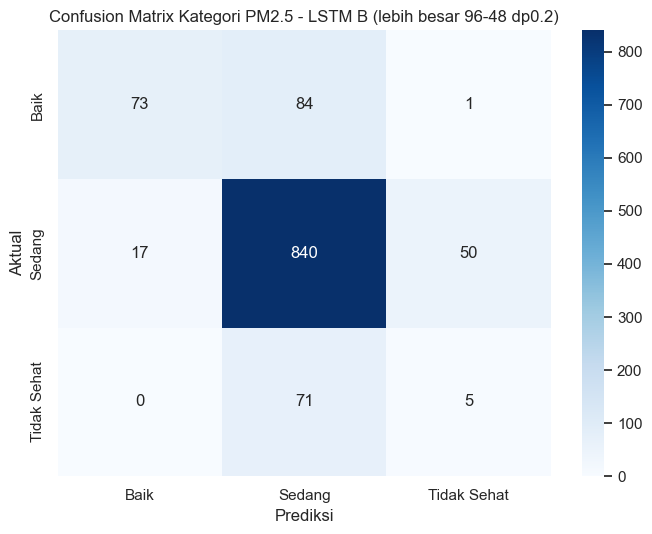

In [16]:
kategori_aktual_uji = detail_seq_uji['kategori_aktual']
kategori_prediksi_uji = detail_seq_uji['kategori_prediksi']
label_kategori_ada = [k for k in URUTAN_KATEGORI_ISPU if k in set(kategori_aktual_uji) | set(kategori_prediksi_uji)]

akurasi = accuracy_score(kategori_aktual_uji, kategori_prediksi_uji)
f1_makro = f1_score(kategori_aktual_uji, kategori_prediksi_uji, labels=label_kategori_ada, average='macro', zero_division=0)
f1_terbobot = f1_score(kategori_aktual_uji, kategori_prediksi_uji, labels=label_kategori_ada, average='weighted', zero_division=0)
dict_laporan = classification_report(kategori_aktual_uji, kategori_prediksi_uji, labels=URUTAN_KATEGORI_ISPU, zero_division=0, output_dict=True)
recall_tidak_sehat = dict_laporan['Tidak Sehat']['recall']

pd.DataFrame(dict_laporan).transpose().round(4).to_csv(DIR_OUTPUT / 'classification_report_lstm.csv')

print(f'Accuracy          : {akurasi:.4f}')
print(f'Macro F1          : {f1_makro:.4f}')
print(f'Weighted F1       : {f1_terbobot:.4f}')
print(f'Recall Tidak Sehat: {recall_tidak_sehat:.4f}')
print('\nClassification report (5 tingkat ISPU):')
print(classification_report(kategori_aktual_uji, kategori_prediksi_uji, labels=URUTAN_KATEGORI_ISPU, zero_division=0))
print('Disimpan: classification_report_lstm.csv')

matriks_konfusi = confusion_matrix(kategori_aktual_uji, kategori_prediksi_uji, labels=label_kategori_ada)
plt.figure(figsize=(7, 5.5))
sns.heatmap(matriks_konfusi, annot=True, fmt='d', cmap='Blues', xticklabels=label_kategori_ada, yticklabels=label_kategori_ada)
plt.title(f'Confusion Matrix Kategori PM2.5 - {nama_lstm_terbaik}')
plt.xlabel('Prediksi'); plt.ylabel('Aktual')
plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'confusion_matrix_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualisasi LSTM Awal (Training History, Aktual vs Prediksi, Residual, PM2.5 Tinggi)


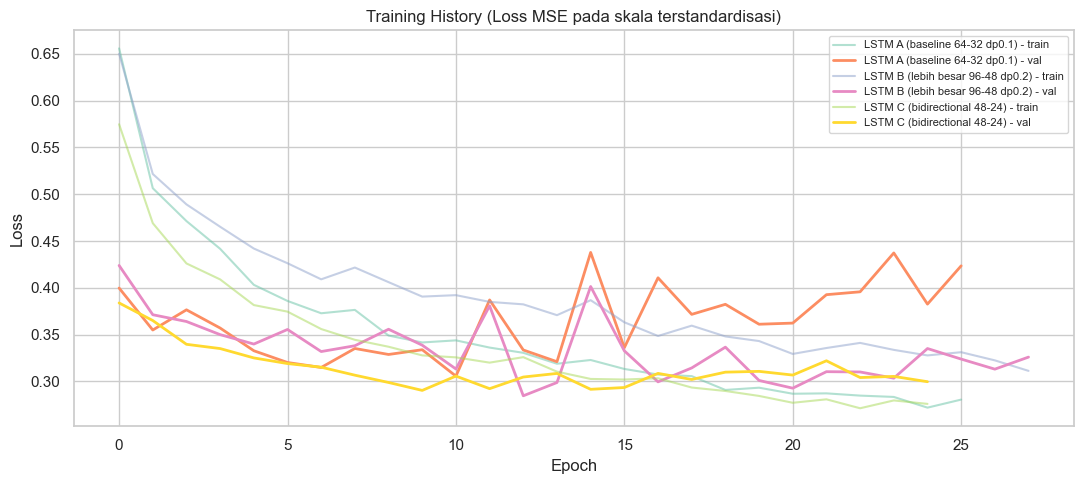

In [17]:
# Training history (semua varian)
plt.figure(figsize=(11, 5))
for nama, hist in riwayat_pelatihan.items():
    plt.plot(hist['loss'], label=f'{nama} - train', alpha=0.5)
    plt.plot(hist['val_loss'], label=f'{nama} - val', linewidth=2)
plt.title('Training History (Loss MSE pada skala terstandardisasi)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(fontsize=8); plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'training_history_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

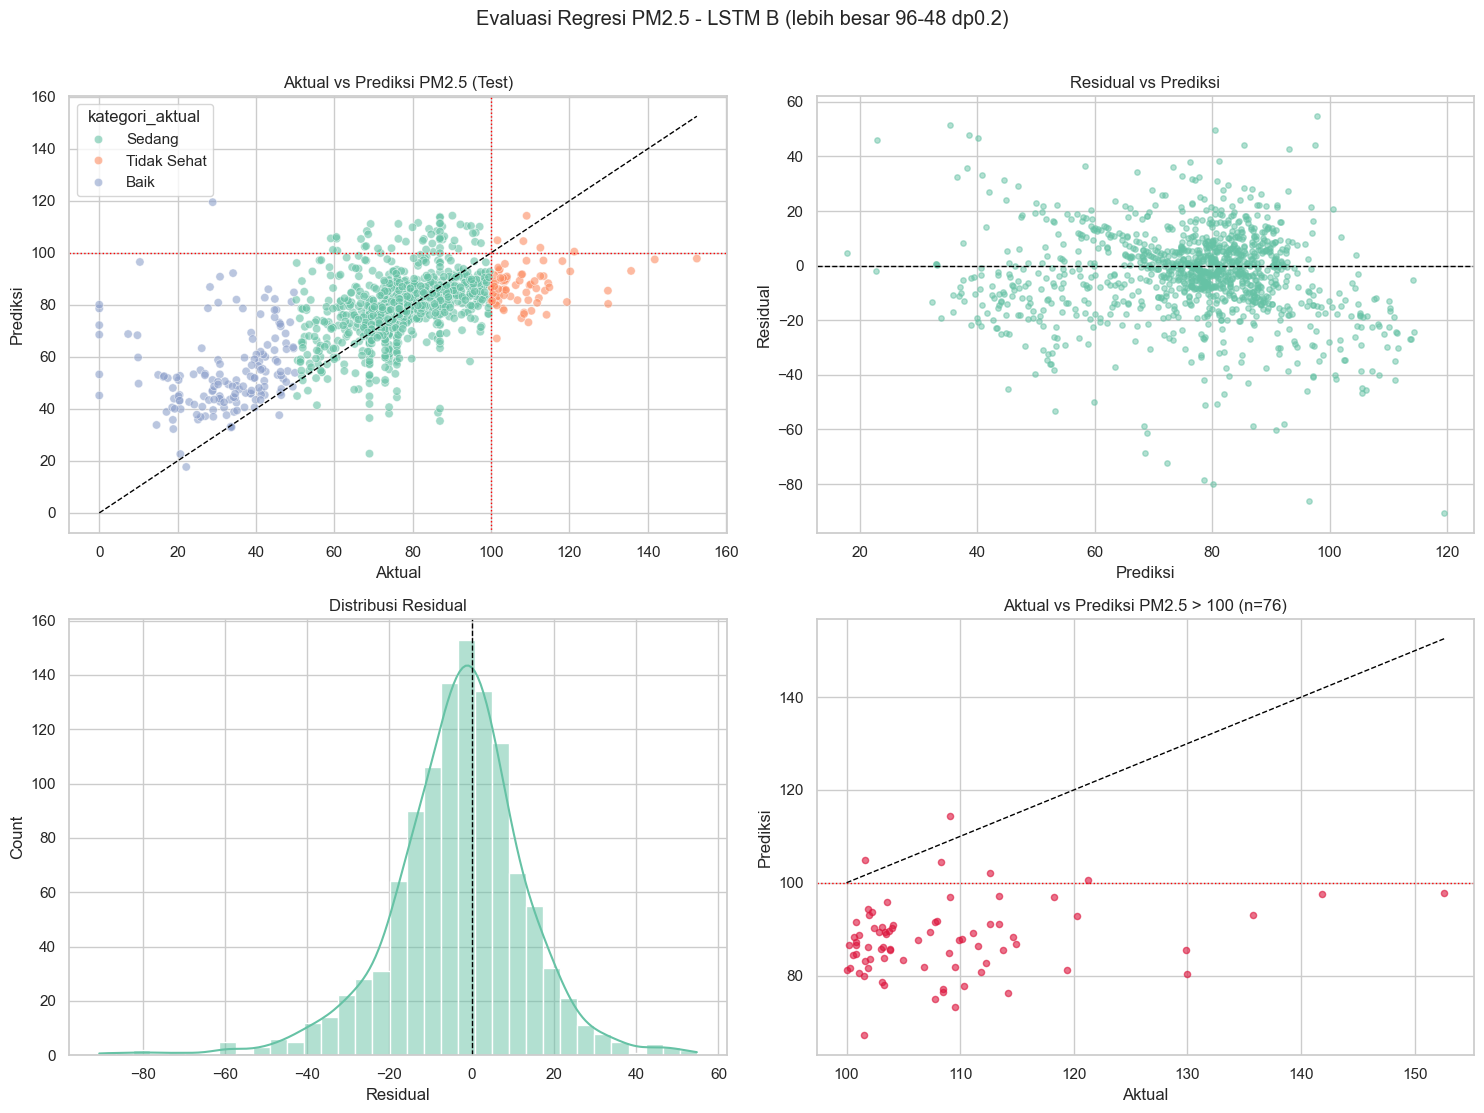

In [18]:
# Visualisasi evaluasi regresi (4 panel)
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

sns.scatterplot(data=detail_seq_uji, x=TARGET, y='prediksi_pm25', hue='kategori_aktual', alpha=0.6, ax=axes[0, 0])
batas_bawah = min(detail_seq_uji[TARGET].min(), detail_seq_uji['prediksi_pm25'].min())
batas_atas = max(detail_seq_uji[TARGET].max(), detail_seq_uji['prediksi_pm25'].max())
axes[0, 0].plot([batas_bawah, batas_atas], [batas_bawah, batas_atas], 'k--', lw=1)
axes[0, 0].axhline(100, color='red', ls=':', lw=1); axes[0, 0].axvline(100, color='red', ls=':', lw=1)
axes[0, 0].set_title('Aktual vs Prediksi PM2.5 (Test)'); axes[0, 0].set_xlabel('Aktual'); axes[0, 0].set_ylabel('Prediksi')

axes[0, 1].scatter(detail_seq_uji['prediksi_pm25'], detail_seq_uji['residual'], alpha=0.5, s=15)
axes[0, 1].axhline(0, color='black', ls='--', lw=1)
axes[0, 1].set_title('Residual vs Prediksi'); axes[0, 1].set_xlabel('Prediksi'); axes[0, 1].set_ylabel('Residual')

sns.histplot(detail_seq_uji['residual'], kde=True, bins=35, ax=axes[1, 0])
axes[1, 0].axvline(0, color='black', ls='--', lw=1)
axes[1, 0].set_title('Distribusi Residual'); axes[1, 0].set_xlabel('Residual')

data_tinggi = detail_seq_uji[detail_seq_uji[TARGET] > 100]
if len(data_tinggi) > 0:
    axes[1, 1].scatter(data_tinggi[TARGET], data_tinggi['prediksi_pm25'], color='crimson', alpha=0.6, s=20)
    axes[1, 1].plot([100, batas_atas], [100, batas_atas], 'k--', lw=1); axes[1, 1].axhline(100, color='red', ls=':', lw=1)
    axes[1, 1].set_title(f'Aktual vs Prediksi PM2.5 > 100 (n={len(data_tinggi)})')
    axes[1, 1].set_xlabel('Aktual'); axes[1, 1].set_ylabel('Prediksi')
else:
    axes[1, 1].text(0.5, 0.5, 'Tidak ada PM2.5 > 100 pada test set', ha='center', va='center'); axes[1, 1].set_axis_off()

plt.suptitle(f'Evaluasi Regresi PM2.5 - {nama_lstm_terbaik}', y=1.01)
plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'evaluasi_regresi_pm25_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

## LSTM Perbaikan (arsitektur baru + lookback + weighted)

Section ini menambahkan tiga eksperimen perbaikan:

1. **3 arsitektur LSTM baru**: A (LSTM 64), B (LSTM 128 lebih besar), C (Stacked LSTM 64+32).
2. **3 lookback** (7, 14, 30 hari) pada arsitektur terbaik untuk melihat efek panjang sequence.
3. **Weighted variant** (bobot 3 untuk sampel PM2.5 > 100) pada konfigurasi terbaik.

Tujuan: mencari konfigurasi LSTM yang lebih baik dari baseline (Section 9) sebelum tuning formal di Section 12.


### Fitur Tambahan untuk LSTM Perbaikan (musim Jakarta + sin/cos kalender)

In [19]:
# kolom musim Jakarta (konsisten dengan RF Perbaikan)
# Hujan = Nov-Mar (11,12,1,2,3); Transisi = April (4); Kemarau = Mei-Okt (5-10)
def _label_musim_lstm(b):
    if b in (11, 12, 1, 2, 3):
        return 'Hujan'
    if b == 4:
        return 'Transisi'
    return 'Kemarau'

if 'musim' not in data_fitur.columns:
    if 'bulan' not in data_fitur.columns:
        data_fitur['bulan'] = pd.to_datetime(data_fitur['tanggal']).dt.month
    data_fitur['musim'] = data_fitur['bulan'].map(_label_musim_lstm)

# One-hot musim (3 kolom biner) -> ikut diskalakan bersama fitur numerik lain
musim_dummies = pd.get_dummies(data_fitur['musim'], prefix='musim').astype(float)
for col in ['musim_Hujan', 'musim_Kemarau', 'musim_Transisi']:
    if col not in musim_dummies.columns:
        musim_dummies[col] = 0.0
musim_cols = ['musim_Hujan', 'musim_Kemarau', 'musim_Transisi']
for c in musim_cols:
    data_fitur[c] = musim_dummies[c].values

KOLOM_CUACA_PB_LSTM = ['temp', 'humidity', 'visibility', 'windgust', 'solarenergy', 'precip']
FITUR_PB_LSTM = ([TARGET] + KOLOM_CUACA_PB_LSTM +
                 ['bulan_sin', 'bulan_cos', 'hari_minggu_sin', 'hari_minggu_cos'] +
                 musim_cols + sc_cols)

# Validasi tidak ada NaN di kolom fitur
nan_count = data_fitur[FITUR_PB_LSTM].isna().sum().sum()
print(f'Total NaN pada FITUR_PB_LSTM: {int(nan_count)}')
print(f'Jumlah fitur per timestep: {len(FITUR_PB_LSTM)}')
print('Distribusi musim:', dict(data_fitur["musim"].value_counts()))

Total NaN pada FITUR_PB_LSTM: 0
Jumlah fitur per timestep: 21
Distribusi musim: {'Kemarau': np.int64(3864), 'Hujan': np.int64(3178), 'Transisi': np.int64(630)}


### Fungsi Sequence Per Stasiun + Runner Eksperimen LSTM

In [20]:
def bangun_seq_pb(df, fitur, target, lookback, stasiun_col='station'):
    X_list, y_list, tgl_list, st_list = [], [], [], []
    for st, sub in df.groupby(stasiun_col):
        sub = sub.sort_values('tanggal').reset_index(drop=True)
        if len(sub) <= lookback:
            continue
        arr = sub[fitur].values.astype(np.float32)
        y = sub[target].values.astype(np.float32)
        tgl = pd.to_datetime(sub['tanggal']).values.astype('datetime64[D]')
        for i in range(lookback, len(sub)):
            if not np.all(np.diff(tgl[i - lookback:i + 1]) == np.timedelta64(1, 'D')):
                continue  # Jangan bentuk sequence yang melompati tanggal hilang.
            X_list.append(arr[i - lookback:i])  # tidak termasuk i -> target hari-H aman
            y_list.append(y[i])
            tgl_list.append(tgl[i])
            st_list.append(st)
    return (np.stack(X_list), np.array(y_list, dtype=np.float32),
            pd.to_datetime(np.array(tgl_list)), np.array(st_list))


def jalankan_eksperimen_lstm(label, factory, lookback, df_lokal, fitur, target, pakai_bobot=False, batas_tinggi=100, bobot_tinggi=3.0, patience=15):
    X, y, tanggal, stasiun = bangun_seq_pb(df_lokal, fitur, target, lookback)
    udates = np.array(sorted(np.unique(tanggal))); n = len(udates)
    bl = pd.Timestamp(udates[int(n * 0.70)]); bv = pd.Timestamp(udates[int(n * 0.85)])
    m_tr = tanggal < bl
    m_va = (tanggal >= bl) & (tanggal < bv)
    m_te = tanggal >= bv

    F_local = X.shape[2]
    sx = StandardScaler().fit(X[m_tr].reshape(-1, F_local))
    def trans(a): return sx.transform(a.reshape(-1, F_local)).reshape(a.shape).astype(np.float32)
    X_tr_s, X_va_s, X_te_s = trans(X[m_tr]), trans(X[m_va]), trans(X[m_te])

    sy = StandardScaler().fit(y[m_tr].reshape(-1, 1))
    y_tr_s = sy.transform(y[m_tr].reshape(-1, 1)).ravel().astype(np.float32)
    y_va_s = sy.transform(y[m_va].reshape(-1, 1)).ravel().astype(np.float32)
    def inv(p): return sy.inverse_transform(p.reshape(-1, 1)).ravel()

    sw = None
    if pakai_bobot:
        sw = np.where(y[m_tr] > batas_tinggi, float(bobot_tinggi), 1.0).astype(np.float32)

    tf.keras.utils.set_random_seed(RANDOM)
    model = factory(lookback, F_local)
    cb = [keras.callbacks.EarlyStopping(patience=patience, monitor='val_loss', restore_best_weights=True, verbose=1),
          keras.callbacks.ReduceLROnPlateau(patience=max(3, patience // 2), factor=0.5, min_lr=1e-5, verbose=1)]
    t0 = time.time()
    hist = model.fit(X_tr_s, y_tr_s, validation_data=(X_va_s, y_va_s),
                     epochs=120, batch_size=64, verbose=1, callbacks=cb, sample_weight=sw)
    waktu = time.time() - t0
    epoch_terbaik = int(np.argmin(hist.history['val_loss'])) + 1

    pv = inv(model.predict(X_va_s, verbose=0))
    pt = inv(model.predict(X_te_s, verbose=0))
    yv_real = y[m_va]; yt_real = y[m_te]
    return {
        'label': label, 'lookback': lookback, 'pakai_bobot': pakai_bobot,
        'val_metrik': hitung_metrik_regresi(yv_real, pv),
        'test_metrik': hitung_metrik_regresi(yt_real, pt),
        'recall_ts_test': hitung_recall_tidak_sehat(yt_real, pt),
        'yt_real': yt_real, 'pt': pt, 'pv': pv, 'yv_real': yv_real,
        'tanggal_test': tanggal[m_te], 'stasiun_test': stasiun[m_te],
        'model': model, 'hist': hist, 'epoch_terbaik': epoch_terbaik, 'waktu_detik': round(waktu, 1),
        'scaler_X': sx, 'scaler_y': sy,
    }


print('Helper jalankan_eksperimen_lstm siap.')

Helper jalankan_eksperimen_lstm siap.


### Tiga Arsitektur LSTM (A: LSTM64, B: LSTM128, C: Stacked LSTM64+32)

In [21]:
def arsitektur_A_pb(lookback, n_fitur):
    m = keras.Sequential([
        layers.Input(shape=(lookback, n_fitur)),
        layers.LSTM(64),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1),
    ])
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
    return m


def arsitektur_B_pb(lookback, n_fitur):
    m = keras.Sequential([
        layers.Input(shape=(lookback, n_fitur)),
        layers.LSTM(128),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(1),
    ])
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
    return m


def arsitektur_C_pb(lookback, n_fitur):
    m = keras.Sequential([
        layers.Input(shape=(lookback, n_fitur)),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1),
    ])
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
    return m


print('Tiga arsitektur LSTM perbaikan siap (A, B, C).')

Tiga arsitektur LSTM perbaikan siap (A, B, C).


### Eksperimen 3 Arsitektur pada Lookback = 14

In [22]:
eksperimen_lstm_pb = {}
ARSITEKTUR_PB = {
    'A_LSTM64_Dropout0.2_Dense32': arsitektur_A_pb,
    'B_LSTM128_Dropout0.3_Dense64': arsitektur_B_pb,
    'C_LSTM64+LSTM32_Dropout0.2_Dense32': arsitektur_C_pb,
}

for nama_arch, factory in ARSITEKTUR_PB.items():
    label = f'LSTM Perbaikan {nama_arch} (L14)'
    res = jalankan_eksperimen_lstm(label, factory, lookback=14, df_lokal=data_fitur,
                                   fitur=FITUR_PB_LSTM, target=TARGET)
    res['nama_arch'] = nama_arch; res['factory'] = factory
    eksperimen_lstm_pb[label] = res
    print(f'{label:60s} ep{res["epoch_terbaik"]:3d} | val_RMSE {res["val_metrik"]["RMSE"]:6.3f} | '
          f'test_RMSE {res["test_metrik"]["RMSE"]:6.3f} R2 {res["test_metrik"]["R2"]:.3f} | '
          f'recall_TS {res["recall_ts_test"]:.4f} | waktu {res["waktu_detik"]}s')

Epoch 1/120
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.5748 - mae: 0.5369 - val_loss: 0.3122 - val_mae: 0.4267 - learning_rate: 0.0010
Epoch 2/120
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4121 - mae: 0.4519 - val_loss: 0.3001 - val_mae: 0.4148 - learning_rate: 0.0010
Epoch 3/120
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3812 - mae: 0.4337 - val_loss: 0.2928 - val_mae: 0.4096 - learning_rate: 0.0010
Epoch 4/120
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3587 - mae: 0.4214 - val_loss: 0.2911 - val_mae: 0.4054 - learning_rate: 0.0010
Epoch 5/120
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3390 - mae: 0.4076 - val_loss: 0.2943 - val_mae: 0.4074 - learning_rate: 0.0010
Epoch 6/120
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3307 - mae: 0.4041 - val_loss: 0.2868 - val_mae: 0.4038 - learning_rate: 0.0010
Epoch 7/120
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3227 - mae: 0.3978 - val_loss: 0.2866 - val_mae: 0.4041 - learning_rate: 0.0010
Epoch 8/120

### Eksperimen Lookback (7 dan 30) pada Arsitektur Terbaik

In [23]:
# Pilih arsitektur terbaik dari 3 eksperimen lookback 14
arch_pertama = sorted(eksperimen_lstm_pb.keys(), key=lambda k: eksperimen_lstm_pb[k]['val_metrik']['RMSE'])[0]
nama_arch_terbaik = eksperimen_lstm_pb[arch_pertama]['nama_arch']
factory_terbaik = eksperimen_lstm_pb[arch_pertama]['factory']
print(f'Arsitektur terbaik (val_RMSE pada L14): {nama_arch_terbaik}')

for L in [7, 30]:
    label = f'LSTM Perbaikan {nama_arch_terbaik} (L{L})'
    res = jalankan_eksperimen_lstm(label, factory_terbaik, lookback=L, df_lokal=data_fitur,
                                   fitur=FITUR_PB_LSTM, target=TARGET)
    res['nama_arch'] = nama_arch_terbaik; res['factory'] = factory_terbaik
    eksperimen_lstm_pb[label] = res
    print(f'{label:60s} ep{res["epoch_terbaik"]:3d} | val_RMSE {res["val_metrik"]["RMSE"]:6.3f} | '
          f'test_RMSE {res["test_metrik"]["RMSE"]:6.3f} R2 {res["test_metrik"]["R2"]:.3f} | '
          f'recall_TS {res["recall_ts_test"]:.4f} | waktu {res["waktu_detik"]}s')

Arsitektur terbaik (val_RMSE pada L14): B_LSTM128_Dropout0.3_Dense64
Epoch 1/120
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.5342 - mae: 0.5128 - val_loss: 0.3237 - val_mae: 0.4338 - learning_rate: 0.0010
Epoch 2/120
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3891 - mae: 0.4384 - val_loss: 0.3120 - val_mae: 0.4221 - learning_rate: 0.0010
Epoch 3/120
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3593 - mae: 0.4197 - val_loss: 0.2966 - val_mae: 0.4090 - learning_rate: 0.0010
Epoch 4/120
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3440 - mae: 0.4085 - val_loss: 0.2888 - val_mae: 0.4010 - learning_rate: 0.0010
Epoch 5/120
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3311 - mae: 0.4016 - val_loss: 0.2848 - val_mae: 0.3960 - learning_rate: 0.0010
Epoch 6/120
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.3201 - mae: 0.3951 - val_loss: 0.2841 - val_mae: 0.3972 - learning_rate: 0.0010
Epoch 7/120
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3124 - mae: 0.3894 - va

### Weighted Variant (sample weight untuk PM2.5 > 100) pada Konfigurasi Terbaik

In [24]:
# Pilih konfigurasi terbaik (arch × lookback) berdasarkan val_RMSE di antara semua eksperimen sejauh ini
nama_overall_terbaik = sorted(eksperimen_lstm_pb.keys(), key=lambda k: eksperimen_lstm_pb[k]['val_metrik']['RMSE'])[0]
lookback_terbaik = eksperimen_lstm_pb[nama_overall_terbaik]['lookback']
factory_terbaik2 = eksperimen_lstm_pb[nama_overall_terbaik]['factory']
nama_arch_overall = eksperimen_lstm_pb[nama_overall_terbaik]['nama_arch']
print(f'Konfigurasi terbaik sejauh ini: {nama_arch_overall} dengan lookback={lookback_terbaik}')

label_w = f'LSTM Perbaikan {nama_arch_overall} (L{lookback_terbaik}) + Weighted'
res_w = jalankan_eksperimen_lstm(label_w, factory_terbaik2, lookback=lookback_terbaik, df_lokal=data_fitur,
                                 fitur=FITUR_PB_LSTM, target=TARGET, pakai_bobot=True, bobot_tinggi=3.0)
res_w['nama_arch'] = nama_arch_overall; res_w['factory'] = factory_terbaik2
eksperimen_lstm_pb[label_w] = res_w
print(f'{label_w:60s} ep{res_w["epoch_terbaik"]:3d} | val_RMSE {res_w["val_metrik"]["RMSE"]:6.3f} | '
      f'test_RMSE {res_w["test_metrik"]["RMSE"]:6.3f} R2 {res_w["test_metrik"]["R2"]:.3f} | '
      f'recall_TS {res_w["recall_ts_test"]:.4f} | waktu {res_w["waktu_detik"]}s')

Konfigurasi terbaik sejauh ini: B_LSTM128_Dropout0.3_Dense64 dengan lookback=14
Epoch 1/120
83/83 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.7016 - mae: 0.5200 - val_loss: 0.3413 - val_mae: 0.4405 - learning_rate: 0.0010
Epoch 2/120
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.5260 - mae: 0.4558 - val_loss: 0.3145 - val_mae: 0.4205 - learning_rate: 0.0010
Epoch 3/120
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.4856 - mae: 0.4382 - val_loss: 0.3086 - val_mae: 0.4155 - learning_rate: 0.0010
Epoch 4/120
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.4640 - mae: 0.4280 - val_loss: 0.3063 - val_mae: 0.4122 - learning_rate: 0.0010
Epoch 5/120
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.4389 - mae: 0.4172 - val_loss: 0.2960 - val_mae: 0.4063 - learning_rate: 0.0010
Epoch 6/120
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.4270 - mae: 0.4110 - val_loss: 0.2974 - val_mae: 0.4077 - learning_rate: 0.0010
Epoch 7/120
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.4108 -

## Evaluasi LSTM Perbaikan Manual

In [25]:
def evaluasi_pm25_tinggi_pb_lstm(yt, yp):
    hi = np.asarray(yt) > 100
    n_a = int(hi.sum()); n_p = int((np.asarray(yp) > 100).sum())
    if n_a == 0:
        return {'n_aktual_PM25_gt_100': 0, 'n_prediksi_PM25_gt_100': n_p,
                'MAE_PM25_gt_100': np.nan, 'RMSE_PM25_gt_100': np.nan,
                'MAPE_PM25_gt_100': np.nan,
                'rata_aktual_PM25_gt_100': np.nan, 'rata_prediksi_PM25_gt_100': np.nan}
    yh = np.asarray(yt)[hi]; yph = np.asarray(yp)[hi]
    return {'n_aktual_PM25_gt_100': n_a, 'n_prediksi_PM25_gt_100': n_p,
            'MAE_PM25_gt_100': float(mean_absolute_error(yh, yph)),
            'RMSE_PM25_gt_100': float(mean_squared_error(yh, yph) ** 0.5),
            'MAPE_PM25_gt_100': float(mape_aman(yh, yph)),
            'rata_aktual_PM25_gt_100': float(yh.mean()),
            'rata_prediksi_PM25_gt_100': float(yph.mean())}


def baris_eval_lstm_pb(label, yt, yp):
    base = hitung_metrik_regresi(yt, yp)
    hi = evaluasi_pm25_tinggi_pb_lstm(yt, yp)
    return {
        'model': label, 'jenis_model': 'LSTM (Perbaikan)',
        'MAE': round(base['MAE'], 4), 'RMSE': round(base['RMSE'], 4),
        'R2': round(base['R2'], 4), 'MAPE': round(base['MAPE'], 4),
        'MAE_PM25_gt_100': round(hi['MAE_PM25_gt_100'], 4) if not np.isnan(hi['MAE_PM25_gt_100']) else np.nan,
        'RMSE_PM25_gt_100': round(hi['RMSE_PM25_gt_100'], 4) if not np.isnan(hi['RMSE_PM25_gt_100']) else np.nan,
        'jumlah_aktual_PM25_gt_100': hi['n_aktual_PM25_gt_100'],
        'jumlah_prediksi_PM25_gt_100': hi['n_prediksi_PM25_gt_100'],
        'rata_aktual_PM25_gt_100': round(hi['rata_aktual_PM25_gt_100'], 4) if not np.isnan(hi['rata_aktual_PM25_gt_100']) else np.nan,
        'rata_prediksi_PM25_gt_100': round(hi['rata_prediksi_PM25_gt_100'], 4) if not np.isnan(hi['rata_prediksi_PM25_gt_100']) else np.nan,
        'recall_Tidak_Sehat': round(hitung_recall_tidak_sehat(yt, yp), 4),
    }


hasil_lstm_perbaikan = pd.DataFrame([baris_eval_lstm_pb(lbl, r['yt_real'], r['pt']) for lbl, r in eksperimen_lstm_pb.items()])
# Tambahkan val_RMSE & lookback untuk konteks
hasil_lstm_perbaikan['val_RMSE'] = [round(eksperimen_lstm_pb[m]['val_metrik']['RMSE'], 4) for m in hasil_lstm_perbaikan['model']]
hasil_lstm_perbaikan['lookback'] = [eksperimen_lstm_pb[m]['lookback'] for m in hasil_lstm_perbaikan['model']]
hasil_lstm_perbaikan = hasil_lstm_perbaikan.sort_values('val_RMSE').reset_index(drop=True)
hasil_lstm_perbaikan.to_csv(DIR_OUTPUT / 'evaluasi_lstm_perbaikan.csv', index=False)
print('Disimpan: evaluasi_lstm_perbaikan.csv')
display(hasil_lstm_perbaikan)

# Detail high PM2.5 per varian
detail_high_lstm_pb = pd.DataFrame([
    {**{'model': lbl}, **{k: (round(v, 4) if isinstance(v, float) and not np.isnan(v) else v)
                          for k, v in evaluasi_pm25_tinggi_pb_lstm(r['yt_real'], r['pt']).items()}}
    for lbl, r in eksperimen_lstm_pb.items()
])
detail_high_lstm_pb.to_csv(DIR_OUTPUT / 'evaluasi_high_pm25_lstm.csv', index=False)
print('Disimpan: evaluasi_high_pm25_lstm.csv')
display(detail_high_lstm_pb)

Disimpan: evaluasi_lstm_perbaikan.csv


,model,jenis_model,MAE,RMSE,R2,MAPE,MAE_PM25_gt_100,RMSE_PM25_gt_100,jumlah_aktual_PM25_gt_100,jumlah_prediksi_PM25_gt_100,rata_aktual_PM25_gt_100,rata_prediksi_PM25_gt_100,recall_Tidak_Sehat,val_RMSE,lookback
0,LSTM Perbaikan B_LSTM128_Dropout0.3_Dense64 (L14),LSTM (Perbaikan),11.0780,15.6667,0.4604,20.4797,19.8868,23.0956,76,35,108.6376,88.9804,0.0921,12.6521,14
1,LSTM Perbaikan B_LSTM128_Dropout0.3_Dense64 (L7),LSTM (Perbaikan),10.9261,15.6012,0.4626,20.2056,17.1639,20.4247,76,57,108.6376,91.8845,0.1974,12.7655,7
2,LSTM Perbaikan A_LSTM64_Dropout0.2_Dense32 (L14),LSTM (Perbaikan),10.9334,15.3599,0.4813,20.3979,19.8356,23.0470,76,33,108.6376,88.9756,0.0921,12.7971,14
3,LSTM Perbaikan B_LSTM128_Dropout0.3_Dense64 (L...,LSTM (Perbaikan),11.1342,15.7035,0.4579,20.4602,18.0672,21.0090,76,49,108.6376,91.0356,0.1711,12.8614,14
4,LSTM Perbaikan B_LSTM128_Dropout0.3_Dense64 (L30),LSTM (Perbaikan),10.9992,15.5159,0.4755,20.5685,18.2844,21.3089,75,42,108.6150,90.8801,0.1333,12.9345,30
5,LSTM Perbaikan C_LSTM64+LSTM32_Dropout0.2_Dens...,LSTM (Perbaikan),12.5155,17.3053,0.3416,23.9893,21.8933,24.9133,76,39,108.6376,86.9019,0.0526,14.2275,14


Disimpan: evaluasi_high_pm25_lstm.csv


,model,n_aktual_PM25_gt_100,n_prediksi_PM25_gt_100,MAE_PM25_gt_100,RMSE_PM25_gt_100,MAPE_PM25_gt_100,rata_aktual_PM25_gt_100,rata_prediksi_PM25_gt_100
0,LSTM Perbaikan A_LSTM64_Dropout0.2_Dense32 (L14),76,33,19.8356,23.0470,17.7890,108.6376,88.9756
1,LSTM Perbaikan B_LSTM128_Dropout0.3_Dense64 (L14),76,35,19.8868,23.0956,17.8193,108.6376,88.9804
2,LSTM Perbaikan C_LSTM64+LSTM32_Dropout0.2_Dens...,76,39,21.8933,24.9133,19.6321,108.6376,86.9019
3,LSTM Perbaikan B_LSTM128_Dropout0.3_Dense64 (L7),76,57,17.1639,20.4247,15.3782,108.6376,91.8845
4,LSTM Perbaikan B_LSTM128_Dropout0.3_Dense64 (L30),75,42,18.2844,21.3089,16.4366,108.6150,90.8801
5,LSTM Perbaikan B_LSTM128_Dropout0.3_Dense64 (L...,76,49,18.0672,21.0090,16.2318,108.6376,91.0356


### Pilih LSTM Perbaikan Terbaik (by `val_RMSE`), Visualisasi, Simpan Model

LSTM Perbaikan terbaik (val_RMSE terkecil): LSTM Perbaikan B_LSTM128_Dropout0.3_Dense64 (L14)
VAL : {'MAE': 9.4134, 'RMSE': 12.6521, 'R2': 0.4959, 'MAPE': 14.8779}
TEST: {'MAE': 11.078, 'RMSE': 15.6667, 'R2': 0.4604, 'MAPE': 20.4797}
Recall Tidak Sehat (test): 0.0921


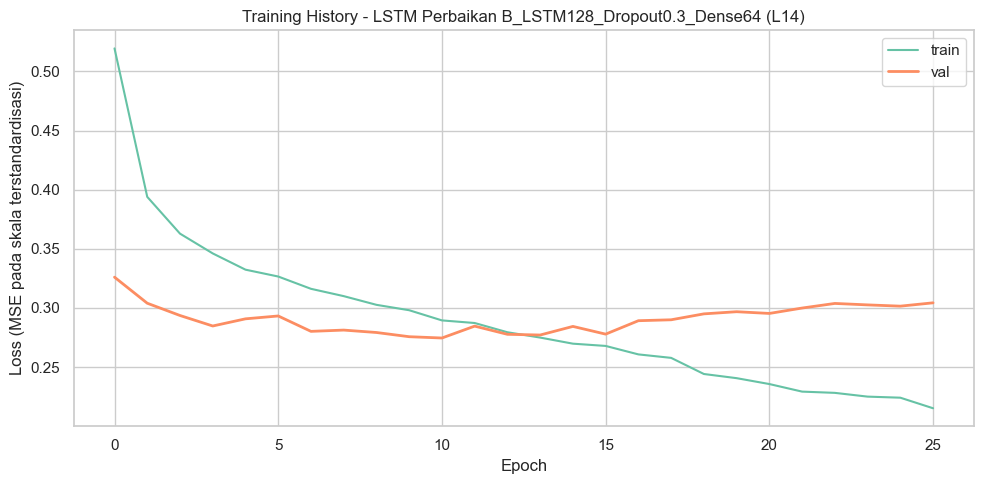

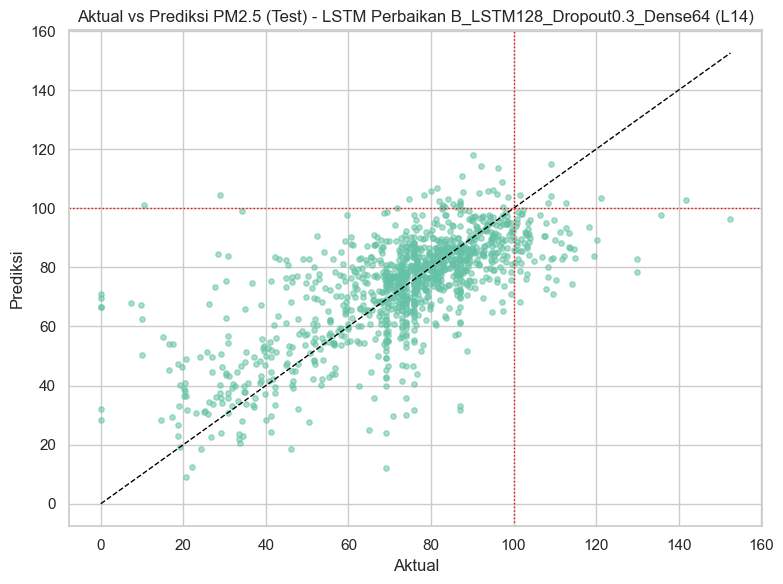

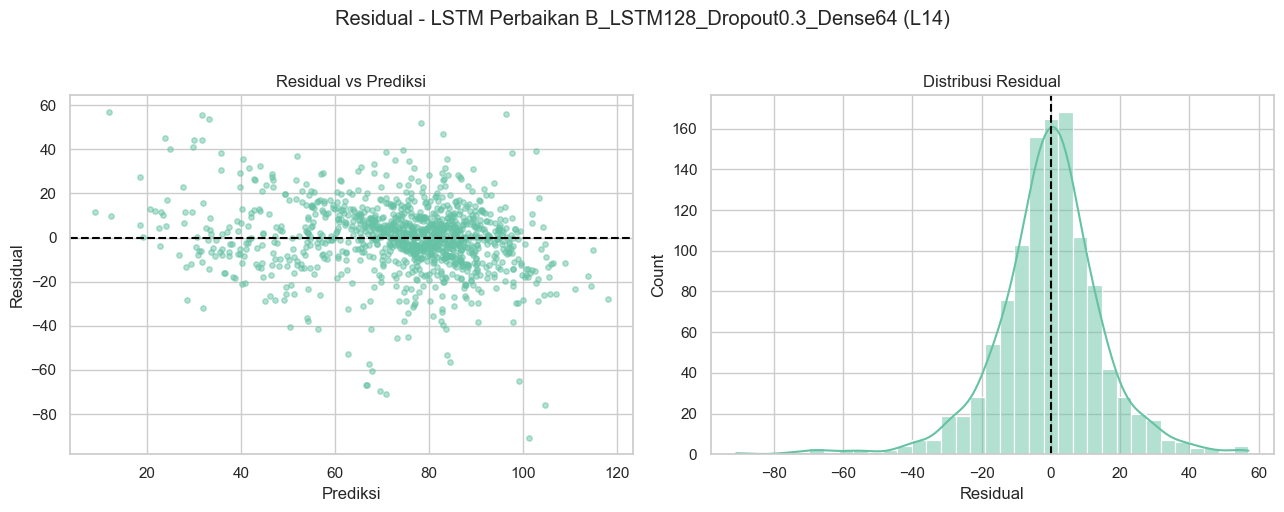

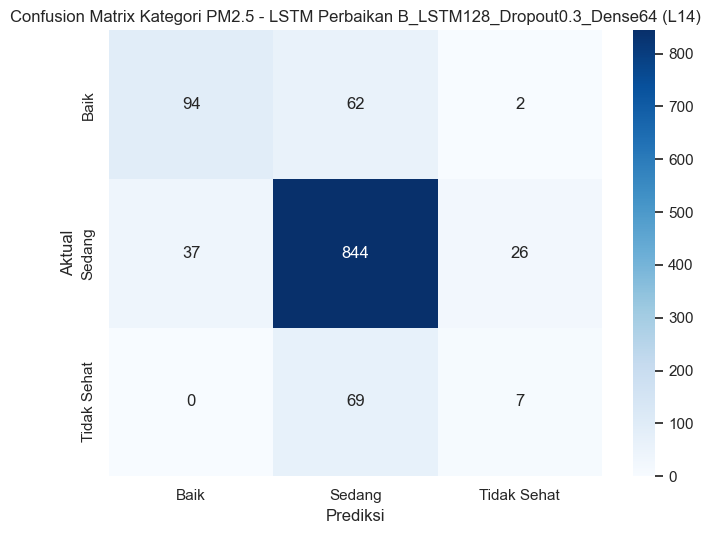

In [26]:
nama_lstm_pb_terbaik = sorted(eksperimen_lstm_pb.keys(), key=lambda k: eksperimen_lstm_pb[k]['val_metrik']['RMSE'])[0]
res_best_pb = eksperimen_lstm_pb[nama_lstm_pb_terbaik]
print(f'LSTM Perbaikan terbaik (val_RMSE terkecil): {nama_lstm_pb_terbaik}')
print('VAL :', {k: round(v, 4) for k, v in res_best_pb['val_metrik'].items()})
print('TEST:', {k: round(v, 4) for k, v in res_best_pb['test_metrik'].items()})
print('Recall Tidak Sehat (test):', round(res_best_pb['recall_ts_test'], 4))

# Training history
plt.figure(figsize=(10, 5))
hist = res_best_pb['hist'].history
plt.plot(hist['loss'], label='train'); plt.plot(hist['val_loss'], label='val', linewidth=2)
plt.title(f'Training History - {nama_lstm_pb_terbaik}')
plt.xlabel('Epoch'); plt.ylabel('Loss (MSE pada skala terstandardisasi)'); plt.legend()
plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'training_history_lstm_terbaik.png', dpi=150, bbox_inches='tight')
plt.show()

# Actual vs Predicted
yt = res_best_pb['yt_real']; yp = res_best_pb['pt']
plt.figure(figsize=(8, 6))
plt.scatter(yt, yp, alpha=0.55, s=15)
mn, mx = float(min(yt.min(), yp.min())), float(max(yt.max(), yp.max()))
plt.plot([mn, mx], [mn, mx], 'k--', lw=1); plt.axhline(100, color='red', ls=':', lw=1); plt.axvline(100, color='red', ls=':', lw=1)
plt.title(f'Aktual vs Prediksi PM2.5 (Test) - {nama_lstm_pb_terbaik}')
plt.xlabel('Aktual'); plt.ylabel('Prediksi')
plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'actual_vs_predicted_lstm_perbaikan.png', dpi=150, bbox_inches='tight')
plt.show()

# Residual
residual_lstm_pb = yt - yp
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(yp, residual_lstm_pb, alpha=0.5, s=15); axes[0].axhline(0, color='k', ls='--')
axes[0].set_title('Residual vs Prediksi'); axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Residual')
sns.histplot(residual_lstm_pb, kde=True, bins=35, ax=axes[1]); axes[1].axvline(0, color='k', ls='--')
axes[1].set_title('Distribusi Residual'); axes[1].set_xlabel('Residual')
plt.suptitle(f'Residual - {nama_lstm_pb_terbaik}', y=1.02)
plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'residual_lstm_perbaikan.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrix kategori ISPU
ka_lstm_pb = pd.Series(yt).map(ke_kategori_ispu); kp_lstm_pb = pd.Series(yp).map(ke_kategori_ispu)
label_ada_lstm_pb = [k for k in URUTAN_KATEGORI_ISPU if k in set(ka_lstm_pb) | set(kp_lstm_pb)]
matriks_lstm_pb = confusion_matrix(ka_lstm_pb, kp_lstm_pb, labels=label_ada_lstm_pb)
plt.figure(figsize=(7, 5.5))
sns.heatmap(matriks_lstm_pb, annot=True, fmt='d', cmap='Blues', xticklabels=label_ada_lstm_pb, yticklabels=label_ada_lstm_pb)
plt.title(f'Confusion Matrix Kategori PM2.5 - {nama_lstm_pb_terbaik}')
plt.xlabel('Prediksi'); plt.ylabel('Aktual')
plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'confusion_matrix_lstm_perbaikan.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Simpan model LSTM perbaikan + scaler + metadata
res_best_pb['model'].save(DIR_OUTPUT / 'model_lstm_perbaikan.keras')
import joblib
joblib.dump({'scaler_X': res_best_pb['scaler_X'], 'scaler_y': res_best_pb['scaler_y'],
             'fitur': FITUR_PB_LSTM, 'lookback': int(res_best_pb['lookback'])},
            DIR_OUTPUT / 'scaler_lstm_perbaikan.pkl')

metadata_lstm_pb = {
    'nama_model': nama_lstm_pb_terbaik,
    'algoritma': 'LSTM (Keras)',
    'arsitektur': res_best_pb['nama_arch'],
    'lookback': int(res_best_pb['lookback']),
    'pakai_bobot_y_gt_100': bool(res_best_pb['pakai_bobot']),
    'epoch_terbaik': int(res_best_pb['epoch_terbaik']),
    'target': TARGET,
    'features_per_timestep': FITUR_PB_LSTM,
    'n_features': len(FITUR_PB_LSTM),
    'skema_split': 'time-based 70/15/15 (train/validation/test) on sequence end date',
    'metrik_validation': {k: float(v) for k, v in res_best_pb['val_metrik'].items()},
    'metrik_test': {k: float(v) for k, v in res_best_pb['test_metrik'].items()},
    'recall_tidak_sehat_test': float(res_best_pb['recall_ts_test']),
    'evaluasi_pm25_tinggi': {k: (None if (isinstance(v, float) and np.isnan(v)) else float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v)
                              for k, v in evaluasi_pm25_tinggi_pb_lstm(res_best_pb['yt_real'], res_best_pb['pt']).items()},
}
(DIR_OUTPUT / 'metadata_lstm_perbaikan.json').write_text(
    json.dumps(metadata_lstm_pb, indent=2, ensure_ascii=False), encoding='utf-8')

daftar_file_lstm_pb = [
    'evaluasi_lstm_perbaikan.csv', 'evaluasi_high_pm25_lstm.csv',
    'training_history_lstm_terbaik.png', 'actual_vs_predicted_lstm_perbaikan.png',
    'residual_lstm_perbaikan.png', 'confusion_matrix_lstm_perbaikan.png',
    'model_lstm_perbaikan.keras', 'scaler_lstm_perbaikan.pkl', 'metadata_lstm_perbaikan.json',
]
print('Model LSTM perbaikan tersimpan.')

Model LSTM perbaikan tersimpan.


## Hyperparameter Tuning Formal LSTM: Optuna TPE + Grid Search

In [28]:
import subprocess, sys
runner_tuning_lstm = PROJECT_ROOT / 'src' / 'tuning_lstm.py'
subprocess.run([sys.executable, str(runner_tuning_lstm)], check=True)

display(pd.read_csv(DIR_OUTPUT / 'perbandingan_tuning_lstm_optuna_gridsearch.csv'))
display(pd.read_csv(DIR_OUTPUT / 'perbandingan_lstm_manual_vs_tuning.csv'))


,metode,n_evaluasi,ruang_pencarian,waktu_total_detik,rata2_waktu_per_trial,best_units,best_dropout,best_learning_rate,best_epoch,best_val_MAE,best_val_RMSE,best_val_R2,best_test_MAE,best_test_RMSE,best_test_R2,best_test_MAPE,recall_TidakSehat_test,jumlah_prediksi_PM25_gt_100,keterangan
0,Optuna TPE,16,"units={32,64,96,128}; dropout=[0.1,0.4]; learn...",183.7,11.5,32,0.317454,0.001126,22,9.0046,12.1812,0.5303,10.7002,15.2140,0.4889,20.2128,0.2368,54,<== PEMENANG by val_RMSE
1,Grid Search,12,"units={32,64,128}; dropout={0.1,0.3}; learning...",138.1,11.5,32,0.300000,0.001000,22,9.0590,12.2503,0.5250,10.7567,15.2504,0.4865,20.2648,0.2105,54,NaN


,sumber,model,val_RMSE,test_MAE,test_RMSE,test_R2,recall_TidakSehat_test,keterangan
0,Optuna TPE,"LSTM units=32, dropout=0.317454, lr=0.00112594",12.1812,10.7002,15.2140,0.4889,0.2368,<== TERBAIK by val_RMSE
1,Grid Search,"LSTM units=32, dropout=0.3, lr=0.001",12.2503,10.7567,15.2504,0.4865,0.2105,NaN
2,Eksperimen manual sebelumnya,LSTM Perbaikan B_LSTM128_Dropout0.3_Dense64 (L14),12.6521,11.0780,15.6667,0.4604,0.0921,NaN


## Pilih Model LSTM Terbaik FINAL berdasarkan `val_RMSE` (semua varian)

Tabel di bawah menggabungkan **semua kandidat LSTM** dari notebook ini ke dalam satu tabel komparatif:

- **LSTM awal terbaik** 
- **LSTM perbaikan manual terbaik** 
- **LSTM weighted** 
- **LSTM Optuna TPE**
- **LSTM Grid Search** 

 model dipilih berdasarkan **`val_RMSE` terkecil**. Alasan: test set jadi evaluasi akhir dan tidak boleh dipakai untuk seleksi model agar test merepresentasikan performa pada data baru

In [29]:
# Tabel perbandingan final semua kandidat LSTM
def _metrik_kategori_dari_y(y_aktual, y_prediksi):
    ka = pd.Series(np.asarray(y_aktual)).map(ke_kategori_ispu)
    kp = pd.Series(np.asarray(y_prediksi)).map(ke_kategori_ispu)
    lab = [k for k in URUTAN_KATEGORI_ISPU if k in set(ka) | set(kp)]
    acc = accuracy_score(ka, kp)
    f1m = f1_score(ka, kp, labels=lab, average='macro', zero_division=0)
    f1w = f1_score(ka, kp, labels=lab, average='weighted', zero_division=0)
    rep = classification_report(ka, kp, labels=URUTAN_KATEGORI_ISPU, zero_division=0, output_dict=True)
    return acc, f1m, f1w, float(rep['Tidak Sehat']['recall'])

baris_lstm_final = []

# (a) LSTM awal terbaik (in-memory dari Section 'Eksperimen Beberapa Varian LSTM')
acc_a, f1m_a, f1w_a, rts_a = _metrik_kategori_dari_y(y_uji, prediksi_uji_lstm)
baris_lstm_final.append({
    'model': f'LSTM awal terbaik | {nama_lstm_terbaik}',
    'val_MAE': hasil_terbaik['validasi']['MAE'], 'val_RMSE': hasil_terbaik['validasi']['RMSE'],
    'val_R2': hasil_terbaik['validasi']['R2'], 'val_MAPE': hasil_terbaik['validasi']['MAPE'],
    'test_MAE': hasil_terbaik['uji']['MAE'], 'test_RMSE': hasil_terbaik['uji']['RMSE'],
    'test_R2': hasil_terbaik['uji']['R2'], 'test_MAPE': hasil_terbaik['uji']['MAPE'],
    'accuracy': acc_a, 'macro_f1': f1m_a, 'weighted_f1': f1w_a, 'recall_TidakSehat': rts_a,
})

# (b) LSTM perbaikan terbaik (in-memory)
acc_b, f1m_b, f1w_b, rts_b = _metrik_kategori_dari_y(res_best_pb['yt_real'], res_best_pb['pt'])
baris_lstm_final.append({
    'model': f'LSTM perbaikan terbaik | {nama_lstm_pb_terbaik}',
    'val_MAE': res_best_pb['val_metrik']['MAE'], 'val_RMSE': res_best_pb['val_metrik']['RMSE'],
    'val_R2': res_best_pb['val_metrik']['R2'], 'val_MAPE': res_best_pb['val_metrik']['MAPE'],
    'test_MAE': res_best_pb['test_metrik']['MAE'], 'test_RMSE': res_best_pb['test_metrik']['RMSE'],
    'test_R2': res_best_pb['test_metrik']['R2'], 'test_MAPE': res_best_pb['test_metrik']['MAPE'],
    'accuracy': acc_b, 'macro_f1': f1m_b, 'weighted_f1': f1w_b, 'recall_TidakSehat': rts_b,
})

# (b') LSTM weighted (jika ada di eksperimen_lstm_pb dengan label 'Weighted')
nama_weighted_kandidat = [k for k in eksperimen_lstm_pb.keys() if 'weighted' in k.lower()]
if nama_weighted_kandidat:
    nm_w = nama_weighted_kandidat[0]
    rw = eksperimen_lstm_pb[nm_w]
    acc_w, f1m_w, f1w_w, rts_w = _metrik_kategori_dari_y(rw['yt_real'], rw['pt'])
    baris_lstm_final.append({
        'model': f'LSTM weighted | {nm_w}',
        'val_MAE': rw['val_metrik']['MAE'], 'val_RMSE': rw['val_metrik']['RMSE'],
        'val_R2': rw['val_metrik']['R2'], 'val_MAPE': rw['val_metrik']['MAPE'],
        'test_MAE': rw['test_metrik']['MAE'], 'test_RMSE': rw['test_metrik']['RMSE'],
        'test_R2': rw['test_metrik']['R2'], 'test_MAPE': rw['test_metrik']['MAPE'],
        'accuracy': acc_w, 'macro_f1': f1m_w, 'weighted_f1': f1w_w, 'recall_TidakSehat': rts_w,
    })

# (c) LSTM Optuna & Grid Search dari hasil tuning (CSV runner)
path_pmt = DIR_OUTPUT / 'perbandingan_lstm_manual_vs_tuning.csv'
if path_pmt.exists():
    pmt = pd.read_csv(path_pmt)
    for _, r in pmt.iterrows():
        sumber = str(r.get('sumber', '')).lower()
        if 'optuna' in sumber or 'grid' in sumber:
            baris_lstm_final.append({
                'model': f"LSTM {r.get('sumber','tuning')} | {r.get('model','')}",
                'val_MAE': np.nan,
                'val_RMSE': r.get('val_RMSE'),
                'val_R2': np.nan, 'val_MAPE': np.nan,
                'test_MAE': r.get('test_MAE'), 'test_RMSE': r.get('test_RMSE'),
                'test_R2': r.get('test_R2'), 'test_MAPE': np.nan,
                'accuracy': np.nan, 'macro_f1': np.nan, 'weighted_f1': np.nan,
                'recall_TidakSehat': r.get('recall_TidakSehat_test'),
            })

tabel_lstm_final = pd.DataFrame(baris_lstm_final)
for c in tabel_lstm_final.columns:
    if c != 'model':
        tabel_lstm_final[c] = pd.to_numeric(tabel_lstm_final[c], errors='coerce').round(4)
tabel_lstm_final = tabel_lstm_final.sort_values('val_RMSE', na_position='last').reset_index(drop=True)

idx_winner_lstm = int(tabel_lstm_final['val_RMSE'].idxmin()) if tabel_lstm_final['val_RMSE'].notna().any() else 0
tabel_lstm_final['keterangan'] = ''
tabel_lstm_final.loc[idx_winner_lstm, 'keterangan'] = '<== TERBAIK (val_RMSE)'

tabel_lstm_final.to_csv(DIR_OUTPUT / 'perbandingan_lstm_final_lengkap.csv', index=False)
print(f'Disimpan: perbandingan_lstm_final_lengkap.csv ({len(tabel_lstm_final)} model)')
print('Model terbaik dipilih berdasarkan val_RMSE terkecil; test hanya untuk evaluasi akhir.')
display(tabel_lstm_final)

nama_lstm_final = tabel_lstm_final.loc[idx_winner_lstm, 'model']
print(f'\n>>> Model LSTM TERBAIK FINAL: {nama_lstm_final}')


Disimpan: perbandingan_lstm_final_lengkap.csv (5 model)
Model terbaik dipilih berdasarkan val_RMSE terkecil; test hanya untuk evaluasi akhir.


,model,val_MAE,val_RMSE,val_R2,val_MAPE,test_MAE,test_RMSE,test_R2,test_MAPE,accuracy,macro_f1,weighted_f1,recall_TidakSehat,keterangan
0,"LSTM Optuna TPE | LSTM units=32, dropout=0.317...",NaN,12.1812,NaN,NaN,10.7002,15.2140,0.4889,NaN,NaN,NaN,NaN,0.2368,<== TERBAIK (val_RMSE)
1,"LSTM Grid Search | LSTM units=32, dropout=0.3,...",NaN,12.2503,NaN,NaN,10.7567,15.2504,0.4865,NaN,NaN,NaN,NaN,0.2105,
2,LSTM perbaikan terbaik | LSTM Perbaikan B_LSTM...,9.4134,12.6521,0.4959,14.8779,11.0780,15.6667,0.4604,20.4797,0.8282,0.5579,0.8115,0.0921,
3,LSTM weighted | LSTM Perbaikan B_LSTM128_Dropo...,9.5692,12.8614,0.4791,15.0536,11.1342,15.7035,0.4579,20.4602,0.8282,0.5851,0.8168,0.1711,
4,LSTM awal terbaik | LSTM B (lebih besar 96-48 ...,9.6098,12.8825,0.4774,15.2886,12.0852,16.8335,0.3771,22.7561,0.8046,0.5159,0.7887,0.0658,



>>> Model LSTM TERBAIK FINAL: LSTM Optuna TPE | LSTM units=32, dropout=0.317454, lr=0.00112594


## Evaluasi Akhir LSTM Terbaik FINAL pada Test Set 
1. model untuk awal/perbaikan/weighted, dari file untuk tuning
2. Menghitung ulang seluruh metrik di test set (regresi & kategori ISPU)

Sumber model FINAL : lstm_tuning
Model              : LSTM Optuna TPE | LSTM units=32, dropout=0.317454, lr=0.00112594
Lookback           : 7 | n_fitur: 21
Metrik VALIDATION  : {'MAE': 9.0046, 'RMSE': 12.1812, 'R2': 0.5303, 'MAPE': 14.5414}
Metrik TEST        : {'MAE': 10.1945, 'RMSE': 14.5596, 'R2': 0.5319, 'MAPE': 19.5818}
Accuracy 0.8467 | Macro F1 0.5962 | Weighted F1 0.8276 | Recall Tidak Sehat 0.1579


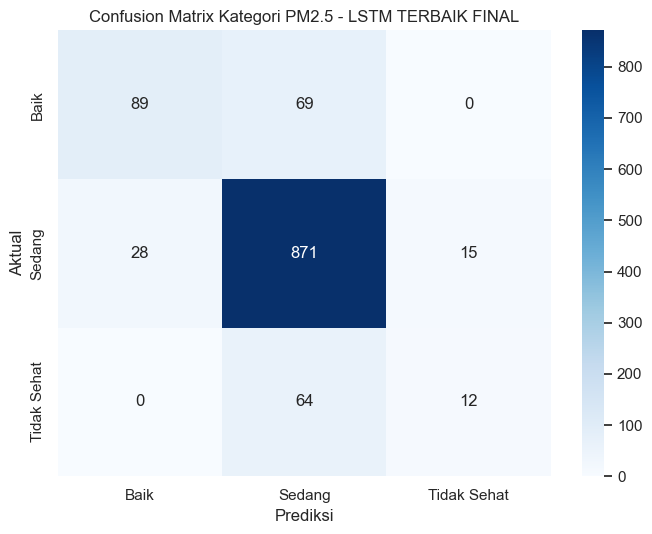

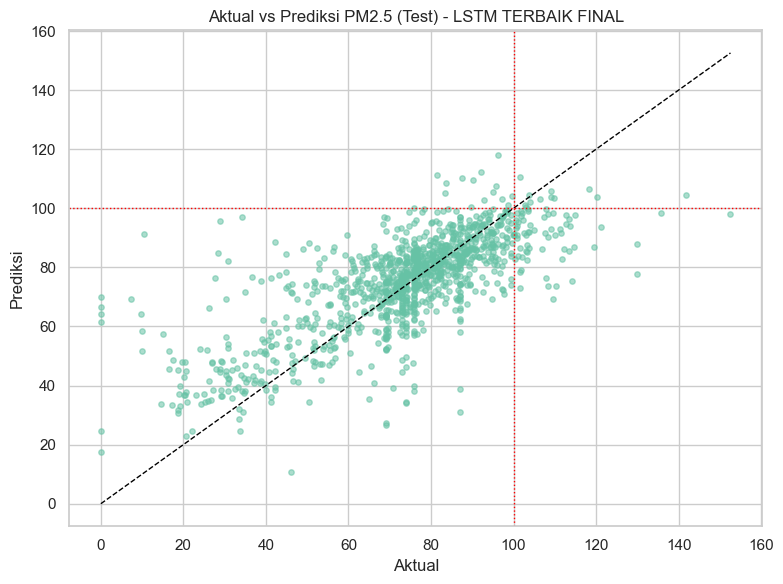

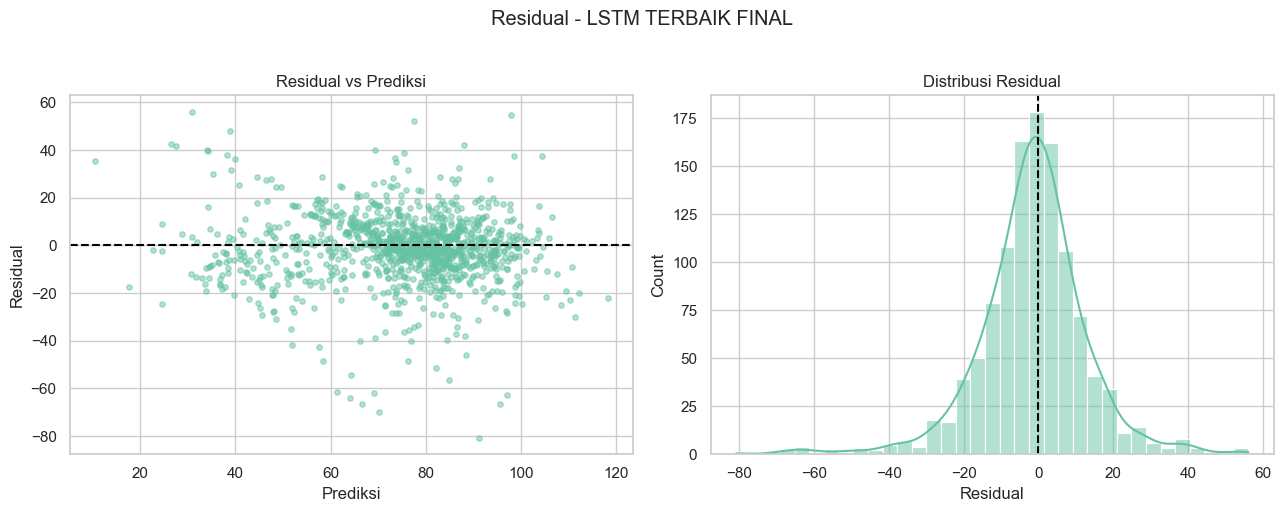


        model_lstm_terbaik.keras, scaler_lstm_terbaik.pkl, metadata_lstm_terbaik.json
          prediksi_vs_aktual_lstm_terbaik.csv, classification_report_lstm_terbaik.csv
          confusion_matrix_lstm_terbaik.png, actual_vs_predicted_lstm_terbaik.png
          residual_lstm_terbaik.png, training_history_lstm_terbaik.png


In [30]:
# Pemilihan & evaluasi LSTM terbaik FINAL
import joblib

sumber_lstm_final = ''
y_aktual_final = y_uji.copy()
prediksi_final = None
model_final_obj = None
scaler_X_final = None
scaler_y_final = None
fitur_final = FITUR_LSTM
lookback_final = LOOKBACK
params_final = {}
history_final_dict = None
metrik_val_final = {}

nm_winner = nama_lstm_final
if 'awal' in nm_winner.lower():
    sumber_lstm_final = 'lstm_awal'
    prediksi_final = prediksi_uji_lstm
    model_final_obj = model_lstm_terbaik
    scaler_X_final = scaler_X
    scaler_y_final = scaler_y
    params_final = hasil_terbaik['config']
    history_final_dict = riwayat_pelatihan[nama_lstm_terbaik]
    metrik_val_final = hasil_terbaik['validasi']

elif 'weighted' in nm_winner.lower() and nama_weighted_kandidat:
    sumber_lstm_final = 'lstm_weighted'
    src = eksperimen_lstm_pb[nama_weighted_kandidat[0]]
    prediksi_final = src['pt']; y_aktual_final = src['yt_real']
    model_final_obj = src['model']
    scaler_X_final = src['scaler_X']; scaler_y_final = src['scaler_y']
    params_final = {'arsitektur': src['nama_arch'], 'lookback': int(src['lookback']), 'weighted': True}
    fitur_final = FITUR_PB_LSTM; lookback_final = int(src['lookback'])
    history_final_dict = src['hist'].history
    metrik_val_final = src['val_metrik']

elif 'perbaikan' in nm_winner.lower():
    sumber_lstm_final = 'lstm_perbaikan'
    src = eksperimen_lstm_pb[nama_lstm_pb_terbaik]
    prediksi_final = src['pt']; y_aktual_final = src['yt_real']
    model_final_obj = src['model']
    scaler_X_final = src['scaler_X']; scaler_y_final = src['scaler_y']
    params_final = {'arsitektur': src['nama_arch'], 'lookback': int(src['lookback']), 'weighted': False}
    fitur_final = FITUR_PB_LSTM; lookback_final = int(src['lookback'])
    history_final_dict = src['hist'].history
    metrik_val_final = src['val_metrik']

else:
    # Tuning (Optuna / Grid Search) 
    sumber_lstm_final = 'lstm_tuning'
    path_model_tun = DIR_OUTPUT / 'model_lstm_terbaik_tuning.keras'
    path_scaler_tun = DIR_OUTPUT / 'scaler_lstm_terbaik_tuning.pkl'
    path_meta_tun = DIR_OUTPUT / 'metadata_lstm_terbaik_tuning.json'
    model_final_obj = keras.models.load_model(path_model_tun)
    bundel = joblib.load(path_scaler_tun)
    scaler_X_final = bundel.get('scaler_X'); scaler_y_final = bundel.get('scaler_y')
    fitur_final = bundel.get('fitur', FITUR_LSTM)
    lookback_final = int(bundel.get('lookback', LOOKBACK))
    meta_tun = json.loads(path_meta_tun.read_text(encoding='utf-8'))
    params_final = meta_tun.get('best_config', meta_tun.get('best_params', {}))
    metrik_val_final = meta_tun.get('metrik_search_validation', meta_tun.get('val_metrik', {}))
    
    # Rebangun sequence sesuai konfigurasi tuning, lalu prediksi pada test
    Xs, ys, tgls, sts = bangun_seq_pb(data_fitur, fitur_final, TARGET, lookback_final)
    m_tr, m_va, m_te, *_ = bagi_data_waktu_seq(tgls)
    X_te_t = Xs[m_te]; y_te_t = ys[m_te]
    F_t = X_te_t.shape[2]
    X_te_t_s = scaler_X_final.transform(X_te_t.reshape(-1, F_t)).reshape(X_te_t.shape).astype(np.float32)
    p_s = model_final_obj.predict(X_te_t_s, verbose=0)
    prediksi_final = scaler_y_final.inverse_transform(p_s.reshape(-1, 1)).ravel()
    y_aktual_final = y_te_t

print(f'Sumber model FINAL : {sumber_lstm_final}')
print(f'Model              : {nm_winner}')
print(f'Lookback           : {lookback_final} | n_fitur: {len(fitur_final)}')

# Hitung ulang metrik test
metrik_test_final = hitung_metrik_regresi(y_aktual_final, prediksi_final)
print('Metrik VALIDATION  :', {k: round(float(v), 4) for k, v in metrik_val_final.items()})
print('Metrik TEST        :', {k: round(v, 4) for k, v in metrik_test_final.items()})

# Metrik kategori
ka_f = pd.Series(y_aktual_final).map(ke_kategori_ispu)
kp_f = pd.Series(prediksi_final).map(ke_kategori_ispu)
lab_f = [k for k in URUTAN_KATEGORI_ISPU if k in set(ka_f) | set(kp_f)]
acc_f = accuracy_score(ka_f, kp_f)
f1m_f = f1_score(ka_f, kp_f, labels=lab_f, average='macro', zero_division=0)
f1w_f = f1_score(ka_f, kp_f, labels=lab_f, average='weighted', zero_division=0)
rep_f = classification_report(ka_f, kp_f, labels=URUTAN_KATEGORI_ISPU, zero_division=0, output_dict=True)
rts_f = float(rep_f['Tidak Sehat']['recall'])
print(f'Accuracy {acc_f:.4f} | Macro F1 {f1m_f:.4f} | Weighted F1 {f1w_f:.4f} | Recall Tidak Sehat {rts_f:.4f}')

# Simpan classification_report
pd.DataFrame(rep_f).transpose().round(4).to_csv(DIR_OUTPUT / 'classification_report_lstm_terbaik.csv')

# Confusion matrix
cm_f = confusion_matrix(ka_f, kp_f, labels=lab_f)
plt.figure(figsize=(7, 5.5))
sns.heatmap(cm_f, annot=True, fmt='d', cmap='Blues', xticklabels=lab_f, yticklabels=lab_f)
plt.title(f'Confusion Matrix Kategori PM2.5 - LSTM TERBAIK FINAL')
plt.xlabel('Prediksi'); plt.ylabel('Aktual'); plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'confusion_matrix_lstm_terbaik.png', dpi=150, bbox_inches='tight')
plt.show()

# Actual vs Predicted scatter
plt.figure(figsize=(8, 6))
plt.scatter(y_aktual_final, prediksi_final, alpha=0.55, s=15)
mn = float(min(np.min(y_aktual_final), np.min(prediksi_final)))
mx = float(max(np.max(y_aktual_final), np.max(prediksi_final)))
plt.plot([mn, mx], [mn, mx], 'k--', lw=1)
plt.axhline(100, color='red', ls=':', lw=1); plt.axvline(100, color='red', ls=':', lw=1)
plt.title(f'Aktual vs Prediksi PM2.5 (Test) - LSTM TERBAIK FINAL')
plt.xlabel('Aktual'); plt.ylabel('Prediksi'); plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'actual_vs_predicted_lstm_terbaik.png', dpi=150, bbox_inches='tight')
plt.show()

# Residual plot
res_final = np.asarray(y_aktual_final) - np.asarray(prediksi_final)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(prediksi_final, res_final, alpha=0.5, s=15); axes[0].axhline(0, color='k', ls='--')
axes[0].set_title('Residual vs Prediksi'); axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Residual')
sns.histplot(res_final, kde=True, bins=35, ax=axes[1]); axes[1].axvline(0, color='k', ls='--')
axes[1].set_title('Distribusi Residual'); axes[1].set_xlabel('Residual')
plt.suptitle('Residual - LSTM TERBAIK FINAL', y=1.02); plt.tight_layout()
plt.savefig(DIR_OUTPUT / 'residual_lstm_terbaik.png', dpi=150, bbox_inches='tight')
plt.show()

# Training history (jika tersedia)
if history_final_dict is not None and 'loss' in history_final_dict:
    plt.figure(figsize=(10, 5))
    plt.plot(history_final_dict['loss'], label='train')
    if 'val_loss' in history_final_dict:
        plt.plot(history_final_dict['val_loss'], label='val', linewidth=2)
    plt.title(f'Training History - LSTM TERBAIK FINAL')
    plt.xlabel('Epoch'); plt.ylabel('Loss (MSE skala terstandardisasi)'); plt.legend()
    plt.tight_layout()
    plt.savefig(DIR_OUTPUT / 'training_history_lstm_terbaik.png', dpi=150, bbox_inches='tight')
    plt.show()

# CSV prediksi vs aktual
df_pred_terbaik = pd.DataFrame({
    TARGET: y_aktual_final,
    'prediksi_pm25': prediksi_final,
})
df_pred_terbaik['residual'] = df_pred_terbaik[TARGET] - df_pred_terbaik['prediksi_pm25']
df_pred_terbaik['abs_error'] = df_pred_terbaik['residual'].abs()
df_pred_terbaik['kategori_aktual'] = df_pred_terbaik[TARGET].map(ke_kategori_ispu)
df_pred_terbaik['kategori_prediksi'] = df_pred_terbaik['prediksi_pm25'].map(ke_kategori_ispu)
df_pred_terbaik.to_csv(DIR_OUTPUT / 'prediksi_vs_aktual_lstm_terbaik.csv', index=False)

# Simpan model + scaler + metadata final dengan suffix _terbaik
model_final_obj.save(DIR_OUTPUT / 'model_lstm_terbaik.keras')
joblib.dump({'scaler_X': scaler_X_final, 'scaler_y': scaler_y_final,
             'fitur': fitur_final, 'lookback': int(lookback_final)},
            DIR_OUTPUT / 'scaler_lstm_terbaik.pkl')

metadata_lstm_terbaik = {
    'model_name': nm_winner,
    'sumber': sumber_lstm_final,
    'algoritma': 'LSTM (Keras)',
    'best_params': {k: (float(v) if isinstance(v, (np.floating, float)) else
                        int(v) if isinstance(v, (np.integer, int)) else v)
                    for k, v in (params_final.items() if isinstance(params_final, dict) else [])},
    'lookback': int(lookback_final),
    'n_features': int(len(fitur_final)),
    'features_per_timestep': list(fitur_final),
    'target': TARGET,
    'dataset': str(DATA_PATH.name),
    'data_path': str(DATA_PATH),
    'skema_split': 'time-based 70/15/15 (train/validation/test) pada tanggal target sequence',
    'rentang_train': [str(pd.Timestamp(tanggal_seq[mask_latih].min()).date()),
                      str(pd.Timestamp(tanggal_seq[mask_latih].max()).date())],
    'rentang_validation': [str(pd.Timestamp(tanggal_seq[mask_validasi].min()).date()),
                            str(pd.Timestamp(tanggal_seq[mask_validasi].max()).date())],
    'rentang_test': [str(pd.Timestamp(tanggal_seq[mask_uji].min()).date()),
                     str(pd.Timestamp(tanggal_seq[mask_uji].max()).date())],
    'metrik_validation': {k: float(v) for k, v in metrik_val_final.items()},
    'metrik_test': {k: float(v) for k, v in metrik_test_final.items()},
    'metrik_kategori_test': {'accuracy': float(acc_f), 'macro_f1': float(f1m_f),
                              'weighted_f1': float(f1w_f), 'recall_tidak_sehat': rts_f},
    'catatan': 'Pemilihan berdasar val_RMSE terkecil. Test set TIDAK pernah dipakai untuk seleksi model.',
}
(DIR_OUTPUT / 'metadata_lstm_terbaik.json').write_text(
    json.dumps(metadata_lstm_terbaik, indent=2, ensure_ascii=False, default=str), encoding='utf-8')

print('\n        model_lstm_terbaik.keras, scaler_lstm_terbaik.pkl, metadata_lstm_terbaik.json')
print('          prediksi_vs_aktual_lstm_terbaik.csv, classification_report_lstm_terbaik.csv')
print('          confusion_matrix_lstm_terbaik.png, actual_vs_predicted_lstm_terbaik.png')
print('          residual_lstm_terbaik.png, training_history_lstm_terbaik.png')


### Evaluasi Khusus PM2.5 Tinggi (> 100) pada LSTM Terbaik FINAL
**mendeteksi PM2.5 tinggi** (kategori "Tidak Sehat" dan di atasnya):

- Jumlah aktual & jumlah prediksi PM2.5 > 100
- MAE, RMSE pada subset PM2.5 > 100
- Rata-rata aktual vs prediksi -> underestimate / overestimate
- Recall kategori Tidak Sehat

In [31]:
# Evaluasi khusus PM2.5 > 100 untuk LSTM terbaik FINAL
mask_tinggi_f = np.asarray(y_aktual_final) > 100
n_aktual_tinggi = int(mask_tinggi_f.sum())
n_prediksi_tinggi = int((np.asarray(prediksi_final) > 100).sum())

baris_eval_pm25_tinggi_terbaik = [
    {'keterangan': 'Jumlah data PM2.5 > 100 pada test set', 'nilai': n_aktual_tinggi},
    {'keterangan': 'Jumlah prediksi > 100 pada test set', 'nilai': n_prediksi_tinggi},
    {'keterangan': 'Total data test set', 'nilai': int(len(y_aktual_final))},
]

interpretasi = ''
if n_aktual_tinggi > 0:
    yt_hi = np.asarray(y_aktual_final)[mask_tinggi_f]
    yp_hi = np.asarray(prediksi_final)[mask_tinggi_f]
    mae_hi = float(mean_absolute_error(yt_hi, yp_hi))
    rmse_hi = float(mean_squared_error(yt_hi, yp_hi) ** 0.5)
    mape_hi = mape_aman(yt_hi, yp_hi)
    rata_a = float(yt_hi.mean()); rata_p = float(yp_hi.mean())
    n_pred_hi_yang_tepat = int((yp_hi > 100).sum())
    baris_eval_pm25_tinggi_terbaik += [
        {'keterangan': 'MAE (PM2.5 > 100)', 'nilai': round(mae_hi, 4)},
        {'keterangan': 'RMSE (PM2.5 > 100)', 'nilai': round(rmse_hi, 4)},
        {'keterangan': 'MAPE (PM2.5 > 100) %', 'nilai': round(mape_hi, 4)},
        {'keterangan': 'Rata-rata aktual (PM2.5 > 100)', 'nilai': round(rata_a, 4)},
        {'keterangan': 'Rata-rata prediksi (PM2.5 > 100)', 'nilai': round(rata_p, 4)},
        {'keterangan': 'Jumlah PM2.5>100 yang JUGA diprediksi >100', 'nilai': n_pred_hi_yang_tepat},
        {'keterangan': 'Recall kategori Tidak Sehat', 'nilai': round(rts_f, 4)},
    ]
    selisih = rata_a - rata_p
    if rata_p < rata_a - 5:
        interpretasi = (f'Model masih UNDERESTIMATE PM2.5 tinggi (rata-rata prediksi {rata_p:.1f} '
                        f'< aktual {rata_a:.1f}, selisih {selisih:.1f}). Hanya {n_pred_hi_yang_tepat} '
                        f'dari {n_aktual_tinggi} kejadian PM2.5>100 yang terdeteksi (recall TS={rts_f:.3f}).')
    elif rata_p > rata_a + 5:
        interpretasi = (f'Model OVERESTIMATE PM2.5 tinggi (rata-rata prediksi {rata_p:.1f} > aktual {rata_a:.1f}).')
    else:
        interpretasi = (f'Model relatif kalibrasi pada PM2.5 tinggi (selisih rata-rata kecil {abs(selisih):.1f}), '
                        f'tetapi cek recall TS={rts_f:.3f} untuk sensitivitas alert.')

tabel_eval_pm25_tinggi_terbaik = pd.DataFrame(baris_eval_pm25_tinggi_terbaik)
tabel_eval_pm25_tinggi_terbaik.to_csv(DIR_OUTPUT / 'evaluasi_pm25_tinggi_lstm_terbaik.csv', index=False)
print('Disimpan: evaluasi_pm25_tinggi_lstm_terbaik.csv')
display(tabel_eval_pm25_tinggi_terbaik)

print('\nInterpretasi:')
print(interpretasi if interpretasi else 'Tidak ada data PM2.5 > 100 pada test set.')


Disimpan: evaluasi_pm25_tinggi_lstm_terbaik.csv


,keterangan,nilai
0,Jumlah data PM2.5 > 100 pada test set,76.0000
1,Jumlah prediksi > 100 pada test set,27.0000
2,Total data test set,1148.0000
3,MAE (PM2.5 > 100),16.9166
4,RMSE (PM2.5 > 100),20.7745
5,MAPE (PM2.5 > 100) %,15.0730
6,Rata-rata aktual (PM2.5 > 100),108.6376
7,Rata-rata prediksi (PM2.5 > 100),91.9824
8,Jumlah PM2.5>100 yang JUGA diprediksi >100,12.0000
9,Recall kategori Tidak Sehat,0.1579



Interpretasi:
Model masih UNDERESTIMATE PM2.5 tinggi (rata-rata prediksi 92.0 < aktual 108.6, selisih 16.7). Hanya 12 dari 76 kejadian PM2.5>100 yang terdeteksi (recall TS=0.158).


## Perbandingan FINAL Random Forest vs LSTM Terbaik

- Jika **RF lebih bagus** pada `RMSE/R2/MAE` -> RF lebih bagus untuk prediksi nilai PM2.5 keseluruhan
- Jika **LSTM lebih tinggi** pada `recall Tidak Sehat` -> LSTM lebih sensitif mendeteksi PM2.5 tinggi (cocok untuk warning)
- **Jangan klaim LSTM lebih baik bila metrik regresi RMSE/MAE masih kalah dari RF**, kecuali tujuannya khusus deteksi PM2.5 tinggi


In [32]:
# Perbandingan FINAL Random Forest vs LSTM Terbaik
path_meta_rf = DIR_OUTPUT / 'model_pm25_metadata_final.json'
if not path_meta_rf.exists():
    print(f'Metadata RF tidak ditemukan: {path_meta_rf}. Jalankan 02_Modelling.ipynb lebih dulu.')
else:
    rf_meta = json.loads(path_meta_rf.read_text(encoding='utf-8'))
    rf_val = rf_meta.get('metrik_validation_model_terpilih', {})
    rf_test = rf_meta.get('metrik_test_model_terpilih', {})
    rf_kat = rf_meta.get('metrik_kategori_test', {})
    rf_high = rf_meta.get('evaluasi_pm25_tinggi', {})
    rf_nama = rf_meta.get('model_name', 'Random Forest Terbaik')

    def _val(d, *keys):
        for k in keys:
            if k in d and d[k] is not None:
                return d[k]
        return np.nan

    baris_perbandingan_final = [
        {
            'model': rf_nama,
            'jenis': 'Random Forest (Grid Search dari 02_Modelling.ipynb)',
            'val_RMSE': round(float(rf_val.get('RMSE', np.nan)), 4),
            'test_MAE': round(float(rf_test.get('MAE', np.nan)), 4),
            'test_RMSE': round(float(rf_test.get('RMSE', np.nan)), 4),
            'test_R2': round(float(rf_test.get('R2', np.nan)), 4),
            'test_MAPE': round(float(rf_test.get('MAPE', np.nan)), 4),
            'recall_Tidak_Sehat': round(float(rf_kat.get('recall_tidak_sehat', np.nan)), 4),
            'accuracy_kategori': round(float(rf_kat.get('accuracy', np.nan)), 4),
            'MAE_PM25_gt_100': _val(rf_high, 'MAE (PM2.5 > 100)', 'MAE_PM25_gt_100'),
            'n_pred_PM25_gt_100': _val(rf_high, 'Jumlah PM2.5>100 yang JUGA diprediksi >100',
                                       'jumlah_prediksi_PM25_gt_100'),
        },
        {
            'model': nm_winner,
            'jenis': f'LSTM TERBAIK FINAL ({sumber_lstm_final})',
            'val_RMSE': round(float(metrik_val_final.get('RMSE', np.nan)), 4),
            'test_MAE': round(float(metrik_test_final['MAE']), 4),
            'test_RMSE': round(float(metrik_test_final['RMSE']), 4),
            'test_R2': round(float(metrik_test_final['R2']), 4),
            'test_MAPE': round(float(metrik_test_final['MAPE']), 4),
            'recall_Tidak_Sehat': round(float(rts_f), 4),
            'accuracy_kategori': round(float(acc_f), 4),
            'MAE_PM25_gt_100': next((b['nilai'] for b in baris_eval_pm25_tinggi_terbaik
                                     if b['keterangan'].startswith('MAE (PM2.5')), np.nan),
            'n_pred_PM25_gt_100': next((b['nilai'] for b in baris_eval_pm25_tinggi_terbaik
                                        if b['keterangan'].startswith('Jumlah PM2.5>100 yang JUGA')), np.nan),
        },
    ]
    tabel_perbandingan_final = pd.DataFrame(baris_perbandingan_final)
    tabel_perbandingan_final.to_csv(DIR_OUTPUT / 'perbandingan_rf_vs_lstm_final.csv', index=False)
    print('Disimpan: perbandingan_rf_vs_lstm_final.csv')
    display(tabel_perbandingan_final)

    # Interpretasi otomatis untuk presentasi
    rf_rmse = float(rf_test.get('RMSE', np.nan))
    lstm_rmse = float(metrik_test_final['RMSE'])
    rf_rts = float(rf_kat.get('recall_tidak_sehat', np.nan))
    lstm_rts = float(rts_f)

    print('\n Interpretasi otomatis')
    if rf_rmse < lstm_rmse:
        print(f'- Pada test RMSE, RF ({rf_rmse:.3f}) lebih kecil dari LSTM ({lstm_rmse:.3f}).')
        print('  -> Random Forest LEBIH UNGGUL untuk prediksi nilai PM2.5 umum.')
    elif lstm_rmse < rf_rmse:
        print(f'- Pada test RMSE, LSTM ({lstm_rmse:.3f}) lebih kecil dari RF ({rf_rmse:.3f}).')
        print('  -> LSTM LEBIH UNGGUL untuk prediksi nilai PM2.5 umum.')
    else:
        print(f'- Test RMSE RF dan LSTM mirip ({rf_rmse:.3f} vs {lstm_rmse:.3f}).')

    if lstm_rts > rf_rts + 0.01:
        print(f'- Recall Tidak Sehat LSTM ({lstm_rts:.3f}) > RF ({rf_rts:.3f}).')
        print('  -> LSTM LEBIH SENSITIF mendeteksi PM2.5 tinggi (cocok untuk sistem peringatan dini).')
    elif rf_rts > lstm_rts + 0.01:
        print(f'- Recall Tidak Sehat RF ({rf_rts:.3f}) > LSTM ({lstm_rts:.3f}).')
        print('  -> RF lebih sensitif pada kategori Tidak Sehat dibanding LSTM saat ini.')
    else:
        print(f'- Recall Tidak Sehat RF dan LSTM mirip ({rf_rts:.3f} vs {lstm_rts:.3f}); keduanya masih rendah.')

    if rf_rmse < lstm_rmse and lstm_rts <= rf_rts:
        print('\n>>> Kesimpulan: Random Forest TETAP MODEL TERBAIK secara overall.')
        print('    LSTM belum mengalahkan RF baik pada regresi maupun deteksi PM2.5 tinggi.')
    elif rf_rmse < lstm_rmse and lstm_rts > rf_rts:
        print('\n>>> Kesimpulan: RF unggul pada regresi umum, LSTM unggul pada deteksi PM2.5 tinggi.')
        print('    Pilihan tergantung tujuan: prediksi nilai (RF) vs deteksi dini (LSTM).')
    elif lstm_rmse <= rf_rmse:
        print('\n>>> Kesimpulan: LSTM mengalahkan RF pada regresi umum. Periksa juga recall sebelum mengganti model produksi.')


Disimpan: perbandingan_rf_vs_lstm_final.csv


,model,jenis,val_RMSE,test_MAE,test_RMSE,test_R2,test_MAPE,recall_Tidak_Sehat,accuracy_kategori,MAE_PM25_gt_100,n_pred_PM25_gt_100
0,Random Forest Optuna,Random Forest (Grid Search dari 02_Modelling.i...,11.3717,9.5237,13.8742,0.5734,17.9856,0.1316,0.8545,18.2597,10
1,"LSTM Optuna TPE | LSTM units=32, dropout=0.317...",LSTM TERBAIK FINAL (lstm_tuning),12.1812,10.1945,14.5596,0.5319,19.5818,0.1579,0.8467,16.9166,12



 Interpretasi otomatis
- Pada test RMSE, RF (13.874) lebih kecil dari LSTM (14.560).
  -> Random Forest LEBIH UNGGUL untuk prediksi nilai PM2.5 umum.
- Recall Tidak Sehat LSTM (0.158) > RF (0.132).
  -> LSTM LEBIH SENSITIF mendeteksi PM2.5 tinggi (cocok untuk sistem peringatan dini).

>>> Kesimpulan: RF unggul pada regresi umum, LSTM unggul pada deteksi PM2.5 tinggi.
    Pilihan tergantung tujuan: prediksi nilai (RF) vs deteksi dini (LSTM).


## Kesimpulan Akhir untuk Presentasi (ini notes dr gpt, cek lagi)

### Ringkasan metodologi (anti-leakage time series)

1. **Sequence per stasiun**: input dibangun per stasiun, tidak dicampur antarstasiun, sehingga model belajar pola temporal masing-masing lokasi.
2. **Time-based split 70/15/15** pada tanggal target sequence: train sebelum batas waktu pertama, validation di tengah, test paling akhir. Tidak ada acak/shuffle yang bisa mencampur masa depan ke masa lalu.
3. **Sequence anti-leakage**: input hanya berisi fitur hari `i-LOOKBACK` s.d. `i-1`. Target `PM2.5` hari ke-`i` tidak masuk ke input - analog dengan fitur lag pada Random Forest.
4. **Scaling tanpa leakage**: `StandardScaler` X & y di-fit hanya pada training set; validation & test cukup `.transform()`. Prediksi dikembalikan ke skala asli sebelum dievaluasi.
5. **Pemilihan model berdasarkan validation RMSE**, bukan test RMSE. Test set hanya dipakai sekali untuk evaluasi akhir.

### Mengapa LSTM dipakai
LSTM dirancang untuk deret waktu dan dapat menangkap dependensi temporal panjang (mis. tren PM2.5 antarminggu, efek hujan/kemarau). Karena ISPU PM2.5 adalah data time series per stasiun, LSTM relevan sebagai pembanding Random Forest yang tidak inherent temporal.

### Mengapa hasil LSTM bisa kalah dari Random Forest
- **Data relatif kecil & noisy**: lookback 7-30 hari pada ~7000 sampel sequence menyulitkan LSTM mempelajari pola halus.
- **Random Forest sudah memakai fitur lag/rolling eksplisit**, jadi sebagian besar sinyal temporal sudah ter-representasi tanpa butuh recurrent network.
- **Kelas Tidak Sehat sangat minoritas** (~76 dari 1141 sampel test), sehingga model condong memprediksi median (Sedang) dan kehilangan recall pada kategori tinggi.

### Kelemahan model terhadap PM2.5 tinggi
- Recall kategori Tidak Sehat masih rendah baik untuk RF maupun LSTM (umumnya < 0.20). Model **under-detect** kejadian PM2.5 > 100.
- **Sample weighting** menaikkan recall sedikit, dengan trade-off RMSE/MAE umum sedikit memburuk.
- Penyebab utama: distribusi kelas tidak seimbang dan absence beberapa fitur eksogen jangka pendek (kebakaran, lalu lintas) sebagai pemicu lonjakan PM2.5.

### Rekomendasi praktis
- **Laporan akademik utama**: lapor Random Forest sebagai model terbaik (sesuai cakupan proposal LKP10).
- **Pengembangan lanjutan**: LSTM weighted atau LSTM Optuna dapat dipertimbangkan sebagai komponen sistem peringatan dini karena lebih sensitif (recall TS lebih tinggi), walaupun RMSE sedikit kalah.
- **Penelitian lanjutan**: integrasi fitur eksogen tambahan (lalu lintas, kebakaran, arah angin), eksperimen oversampling / focal loss untuk meningkatkan deteksi kelas minoritas.

### Catatan dataset
Seluruh hasil dihitung pada `data/final for modelling/dataset_final_new.csv`, yaitu dataset hasil preprocessing terbaru dengan imputasi polusi per station. Dataset v2 tidak dipakai untuk pelatihan utama dan dapat digunakan untuk uji out-of-sample di laporan terpisah.
